In [1]:
import numpy as np
import sys
import time
import h5py
from tqdm import tqdm

import numpy as np
import re
from math import ceil
from sklearn.metrics import average_precision_score
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import pickle
#import pickle5 as pickle

from sklearn.model_selection import train_test_split

from scipy.sparse import load_npz
from glob import glob

from transformers import get_constant_schedule_with_warmup
from sklearn.metrics import precision_score,recall_score,accuracy_score

from src.train import trainModel
from src.dataloader import getData,spliceDataset,h5pyDataset,collate_fn, getDataPointListFull
from src.weight_init import keras_init
from src.losses import categorical_crossentropy_2d
from src.model import SpliceFormer, SpliceAI_10K
from src.evaluation_metrics import print_topl_statistics
import copy
from collections import defaultdict

/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = '../Data'
SL=5000
CL_max=40000
setType = 'test'
annotation_test, transcriptToLabel_test, seqData = getData(data_dir, setType) 

In [28]:
device = torch.device("cpu")
model_m = SpliceFormer(CL_max,determenistic=True, crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)
model_m = nn.DataParallel(model_m)
output_class_labels = ['Null', 'Acceptor', 'Donor']

n_models = 10

model_m.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_0',map_location=device))
model_m.eval()


DataParallel(
  (module): SpliceFormer(
    (SpliceAI): SpliceAI(
      (conv_layer_1): Conv1d(4, 32, kernel_size=(1,), stride=(1,))
      (skip_layers): ModuleList(
        (0-4): 5 x Conv1d(32, 32, kernel_size=(1,), stride=(1,))
      )
      (res_layers): ModuleList(
        (0): ResComboBlock(
          (comboBlock): Sequential(
            (0): ResidualBlock(
              (convlayer1): Conv1d(32, 32, kernel_size=(11,), stride=(1,), padding=(5,))
              (convlayer2): Conv1d(32, 32, kernel_size=(11,), stride=(1,), padding=(5,))
              (activate): ReLU(inplace=True)
              (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
              (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
              (shortcut): Identity()
            )
            (1): ResidualBlock(
              (convlayer1): Conv1d(32, 32, kernel_size=(11,), stride=(1,), padding=(5,))
              (convlayer2): Conv1d

In [3]:
BATCH_SIZE = 1
specific_anno = annotation_test[annotation_test['name'].apply(lambda x: x.split('--')[0])=='CFTR']

In [22]:
test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
l = 1
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    batch_features = batch_chunks.to(torch.float32).to(device)      # shape: [1, 4, 45000]
    targets = torch.squeeze(target_chunks.to(torch.float32).to(device), dim=0)  # shape: [3, 45000]
    
    signal = batch_features[0].sum(dim=0)  # shape: [45000]
    nonzero_positions = torch.nonzero(signal > 0).squeeze()
    print("Transcript spans:", nonzero_positions.min().item(), "to", nonzero_positions.max().item())
    l += 1

    if l >1:
        break

  0%|          | 0/38 [00:00<?, ?it/s]/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
  0%|          | 0/38 [00:00<?, ?it/s]

Transcript spans: 20000 to 44999


In [29]:
# activation = {}
# gradient = {}
# def forward_hook(name):
#     def ahook(model, input, output):
#         activation[name] = output.detach()
#     return ahook

# def backward_hook(name):
#     def ghook(model, grad_input, grad_output):
#         gradient[name] = grad_output.detach()
#     return ghook

activations = []
gradients = []

# Hooks to capture activations and gradients
def forward_hook(model, input, output):
    activations.append(output)

def backward_hook(model, grad_input, grad_output):
    gradients.append(grad_output)

last_res_block = (model_m.module.SpliceAI.res_layers[3].comboBlock[-1])
print(last_res_block)

handle_forward = last_res_block.register_forward_hook(forward_hook)
handle_backward = last_res_block.register_full_backward_hook(backward_hook)

ResidualBlock(
  (convlayer1): Conv1d(32, 32, kernel_size=(41,), stride=(1,), padding=(500,), dilation=(25,))
  (convlayer2): Conv1d(32, 32, kernel_size=(41,), stride=(1,), padding=(500,), dilation=(25,))
  (activate): ReLU(inplace=True)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
  (shortcut): Identity()
)


In [30]:
output = model_m(batch_features)
target = output[0][0,2,20184]
model_m.zero_grad()
target.backward()

In [31]:
activations = torch.mean(activations[0],dim=0)
gradients = torch.mean(gradients[0][0], dim=0)

In [32]:
avg_grad = torch.mean(gradients, dim=1)

weighted_activations = avg_grad.unsqueeze(1) * activations
grad_cam = torch.sum(weighted_activations, dim=0)
relu = torch.nn.ReLU()
grad_cam = relu(grad_cam)
grad_cam = grad_cam.detach().numpy()
grad_cam /= grad_cam.max()

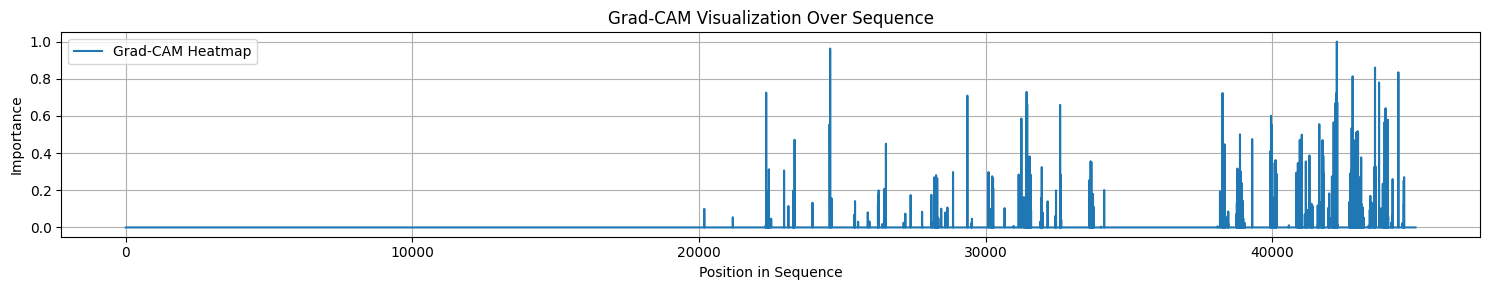

In [33]:
shift = 0
import matplotlib.pyplot as plt
import numpy as np
donor_idx = torch.nonzero(targets[2,:]).numpy() - shift
# gradcam_map is your 1D heatmap (shape: [45000])
plt.figure(figsize=(15, 3))
plt.plot(grad_cam[:], label='Grad-CAM Heatmap')
# plt.scatter(donor_idx, np.ones(len(donor_idx)),c='green',marker="^", clip_on=False, zorder=10,label='Donor')

plt.xlabel('Position in Sequence')
plt.ylabel('Importance')
plt.title('Grad-CAM Visualization Over Sequence')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

handle_forward.remove()
handle_backward.remove()
model_m.zero_grad()
for param in model_m.parameters():
    param.grad = None


### Now taking the average result from the 10 models

In [21]:
from collections import OrderedDict
activations = []
gradients = []

# Hooks to capture activations and gradients
def forward_hook(model, input, output):
    activations.append(output)

def backward_hook(model, grad_input, grad_output):
    gradients.append(grad_output)
    

NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceFormer(CL_max,bn_momentum=0.01/NUM_ACCUMULATION_STEPS,depth=4,heads=4,n_transformer_blocks=2,determenistic=True,crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)
output_class_labels = ['Null', 'Acceptor', 'Donor']

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]

if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/transformer_encoder_45k_171022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] # remove `module.`
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()


for i in range(n_models):
    models[i].SpliceAI.res_layers[3].comboBlock[-1].register_forward_hook(forward_hook)
    models[i].SpliceAI.res_layers[3].comboBlock[-1].register_full_backward_hook(backward_hook)


In [23]:
test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    batch_features = batch_chunks.to(torch.float32).to(device)      # shape: [1, 4, 45000]
    targets = torch.squeeze(target_chunks.to(torch.float32).to(device), dim=0)  # shape: [3, 45000]
    
    signal = batch_features[0].sum(dim=0)  # shape: [45000]
    nonzero_positions = torch.nonzero(signal > 0).squeeze()
    print("Transcript spans:", nonzero_positions.min().item(), "to", nonzero_positions.max().item())

    if i == 4:
        break

  0%|          | 0/38 [00:00<?, ?it/s]/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 11%|█         | 4/38 [00:00<00:00, 399.20it/s]

Transcript spans: 20000 to 44999
Transcript spans: 15000 to 44999
Transcript spans: 10000 to 44999
Transcript spans: 5000 to 44999
Transcript spans: 0 to 44999


In [15]:
acceptor_idxs = np.where(targets[1,:]==1)
donor_idxs = np.where(targets[2,:]==1)
print(acceptor_idxs)
print(donor_idxs)

(array([39290, 44071]),)
(array([15184, 39400, 44179]),)


In [154]:
def plot_single(grad_cam,model,label,idx):
    relu = torch.nn.ReLU()
    grad_cam = relu(grad_cam)
    grad_cam = grad_cam.detach().numpy()
    grad_cam /= grad_cam.max()
    plt.figure(figsize=(15, 3))
    plt.plot(grad_cam, label='Grad-CAM Heatmap')
    plt.scatter(idx, grad_cam[idx],c='green' if label==1 else 'red',marker="^", clip_on=False, zorder=10,label='Donor' if label==1 else 'Acceptor')

    plt.xlabel('Position in Sequence')
    plt.ylabel('Importance')
    plt.title(f'{model}-model Grad-CAM Visualization Over Sequence')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

In [19]:
### RUNNING ALL 10 MODELS, AND THEN TESTING ON INTRONLESS TRANSCRIPT AND THEN MAKING IT ALL INTO A FUNCTION I CAN USE REPEATEDLY
def plot_GradCAM_full(models, batch_features, targets, shift):
    grad_cam_dict = defaultdict(list)
    # grad_cam_full = []
    start,end = 0,45000
    start_shift = 20000
    for j,model in enumerate(models):
        acceptor_idxs = np.where(targets[1,:]==1)
        donor_idxs = np.where(targets[2,:]==1)
        splice_idxs = np.where(targets[1:,:]==1)
        activations.clear()
        gradients.clear()
        for label,idx in zip(splice_idxs[0],splice_idxs[1]):
            activations.clear()
            gradients.clear()
            output = model(batch_features)
            target = output[0][0,label+1,idx]
            model.zero_grad()
            target.backward()
            avg_grad = torch.mean(gradients[0][0], dim=(0,2))
            activation_reduced = torch.mean(activations[0],dim=0)
            weighted_activations = avg_grad.unsqueeze(1) * activation_reduced
            grad_cam = torch.sum(weighted_activations, dim=0)
            # plot_single(grad_cam,j,label,idx)
            grad_cam_dict[idx].append(grad_cam)
            # grad_cam_full.append(grad_cam)
    for label,key in zip(splice_idxs[0],splice_idxs[1]):
        print(key + shift - start_shift)
        grad_cam_key = torch.stack(grad_cam_dict[key])
        grad_cam_key = torch.mean(grad_cam_key,dim=0)
        # grad_cam_key = grad_cam_key[1]
        relu = torch.nn.ReLU()
        grad_cam_key = relu(grad_cam_key)
        grad_cam_key = grad_cam_key.detach().numpy()
        grad_cam_key /= grad_cam_key.max()

        plt.figure(figsize=(15, 3))
        plt.plot(range(start+shift-start_shift,end+shift-start_shift),grad_cam_key, label='Grad-CAM Heatmap')
        if label == 1:
            plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[donor_idxs], grad_cam_key[donor_idxs]+0.005,c='green',marker="^", clip_on=False, zorder=10,label='Donor')
        elif label == 0:
            plt.scatter(np.arange(start+shift-start_shift,end+shift-start_shift)[acceptor_idxs], grad_cam_key[acceptor_idxs]+0.005,c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')

        plt.scatter(key+shift-start_shift, grad_cam_key[key]+0.05,c='black',marker="v", clip_on=False, zorder=10,label='Selected')

        plt.xlabel('Position in Sequence')
        plt.ylabel('Grad-CAM score')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

  0%|          | 0/38 [00:00<?, ?it/s]/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Transcript spans: 20000 to 44999
24290


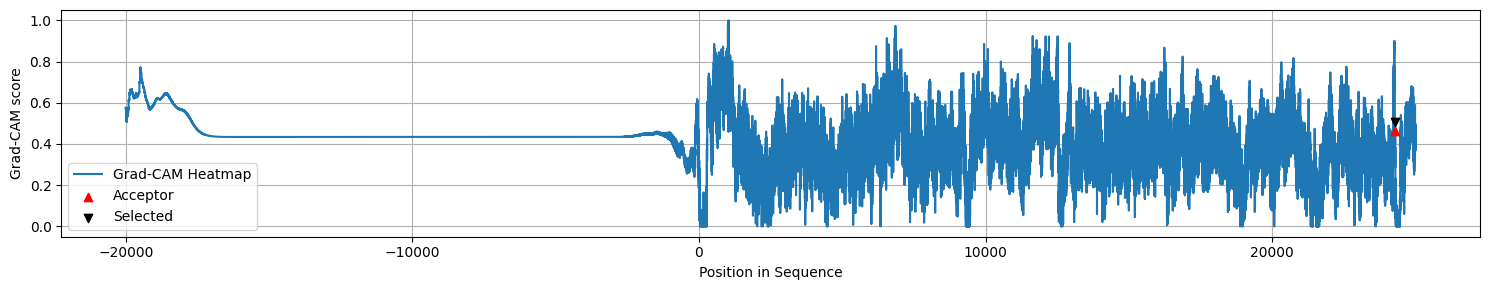

184


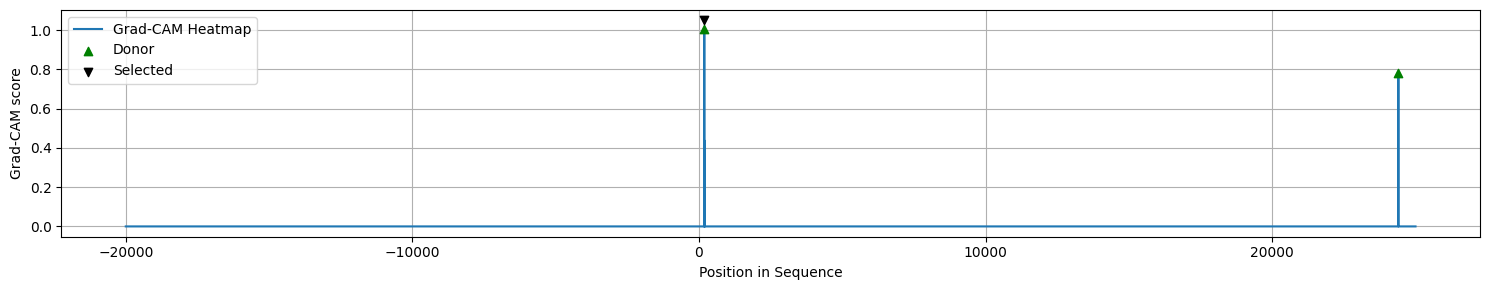

24400


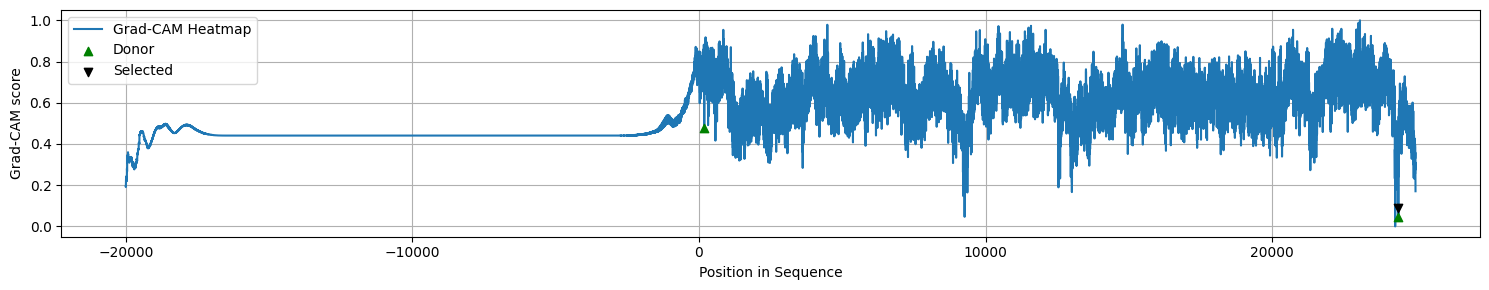

  3%|▎         | 1/38 [01:05<40:29, 65.65s/it]

Transcript spans: 15000 to 44999
24290


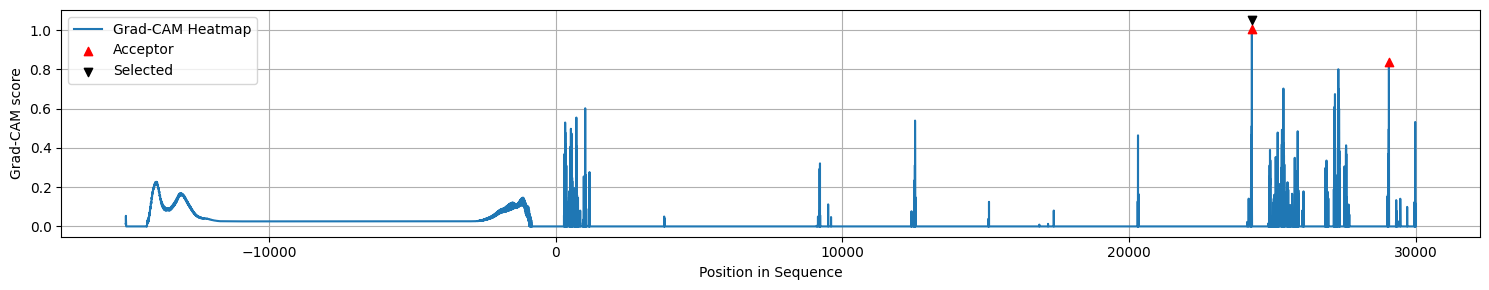

29071


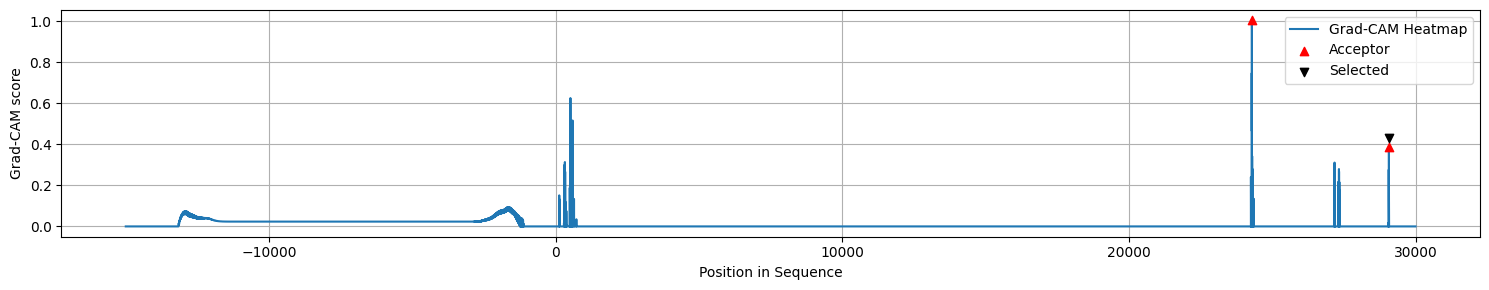

184


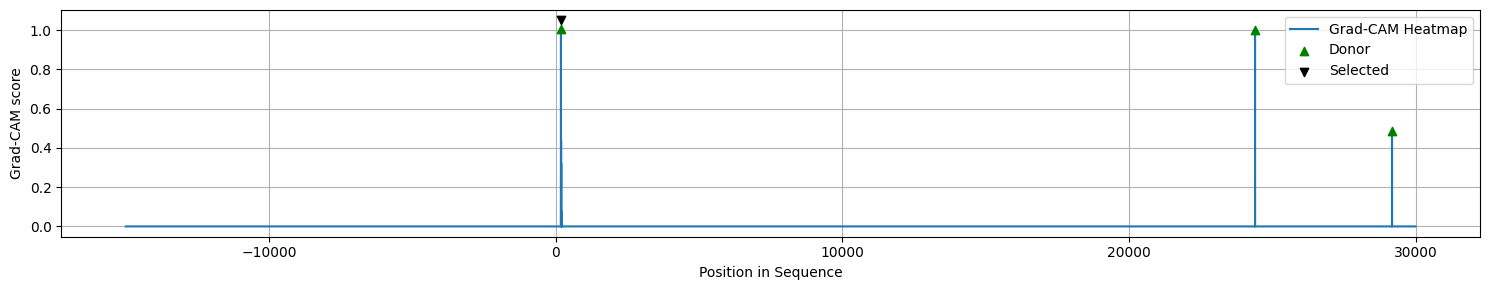

24400


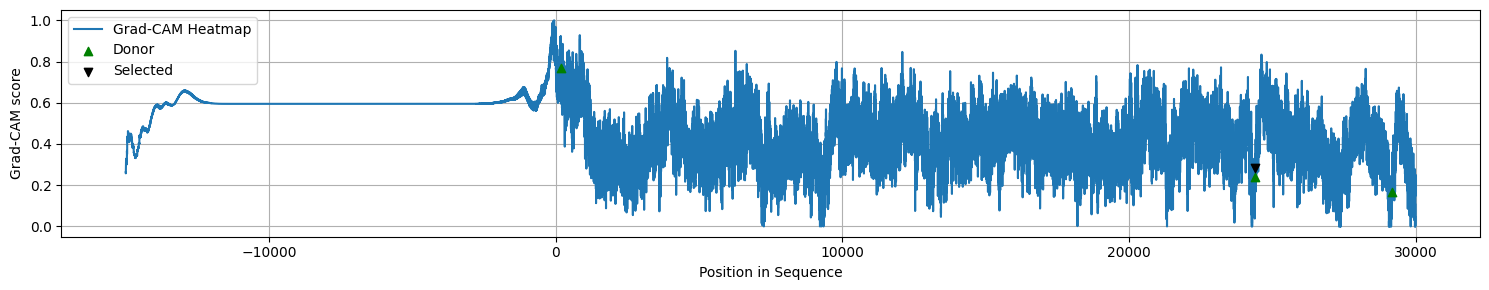

29179


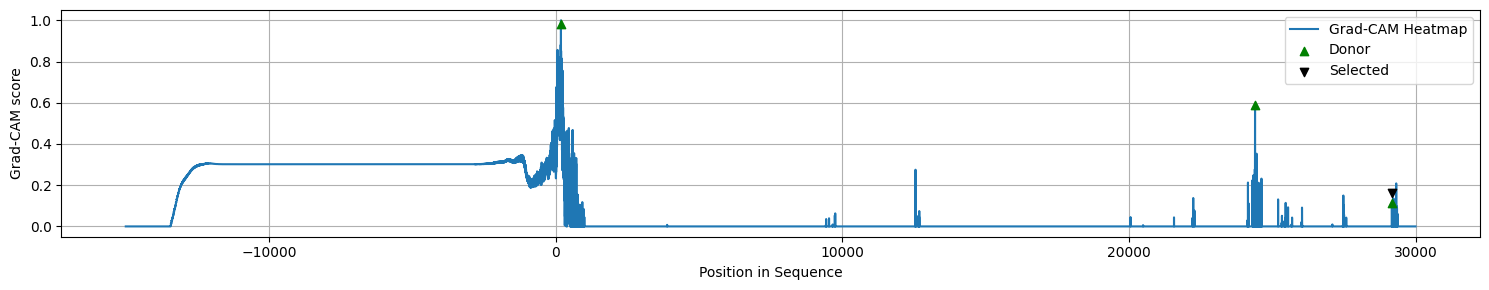

  5%|▌         | 2/38 [02:55<54:49, 91.38s/it]

Transcript spans: 10000 to 44999
24290


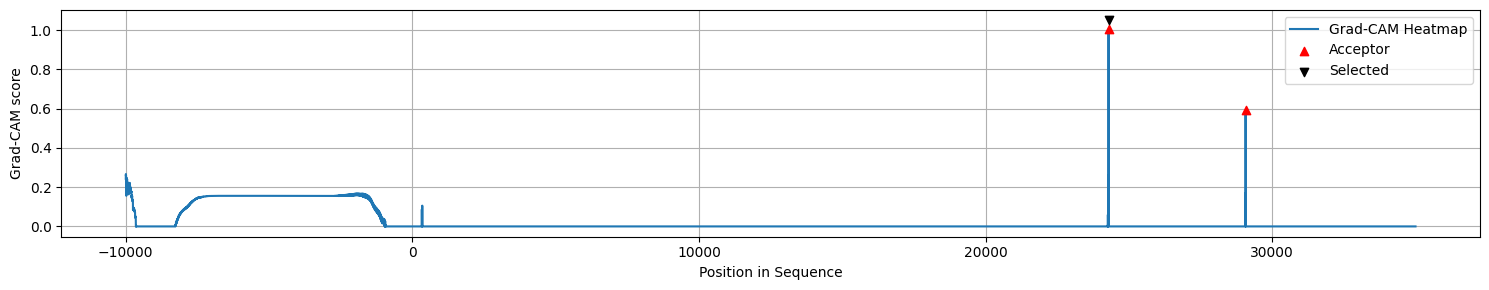

29071


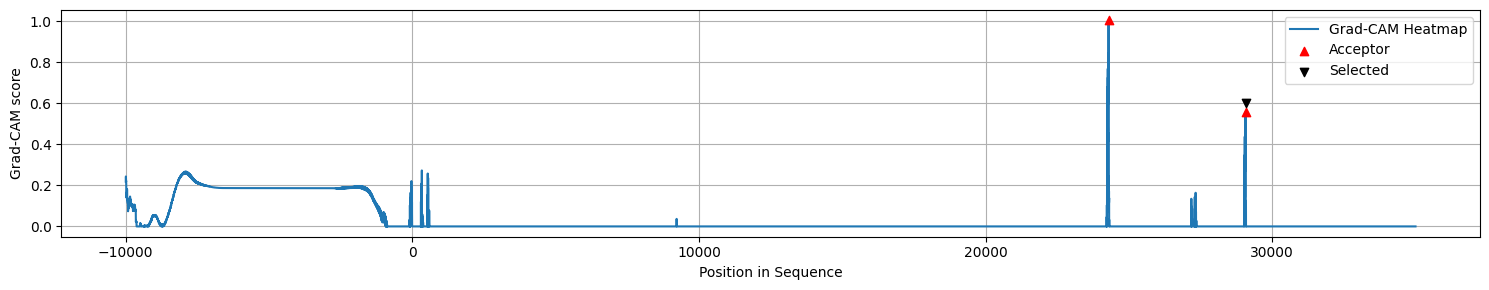

184


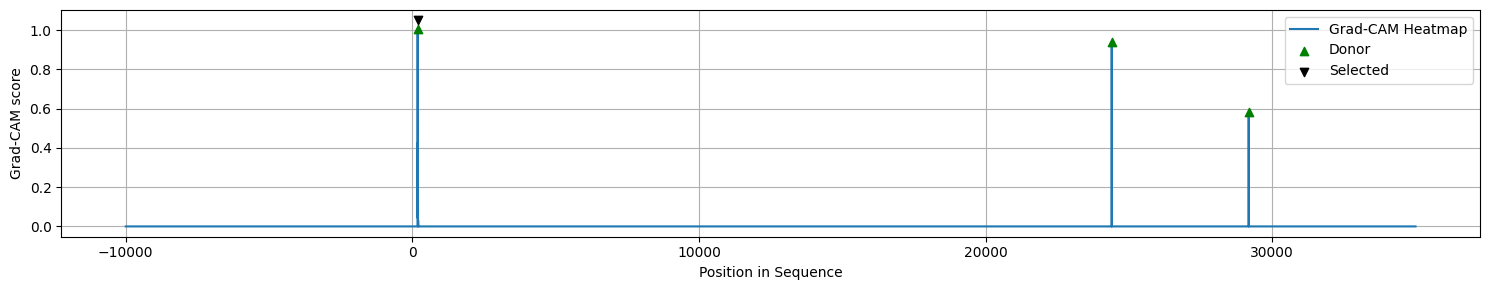

24400


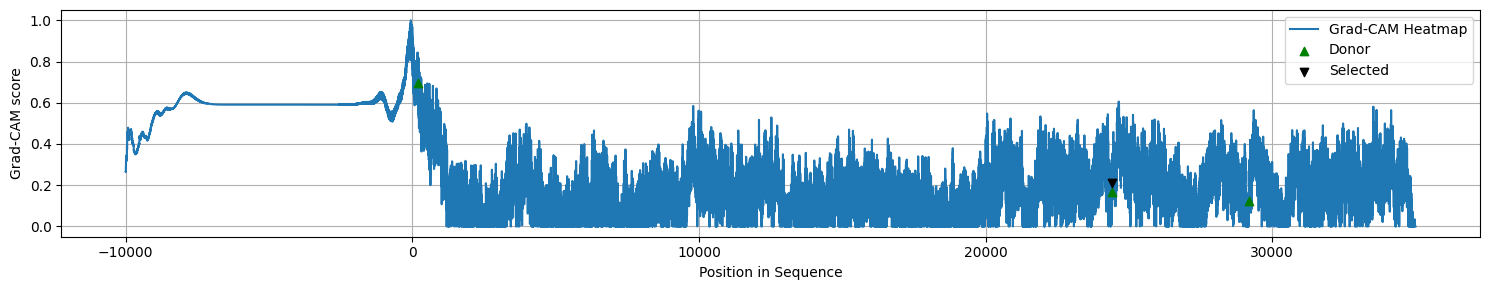

29179


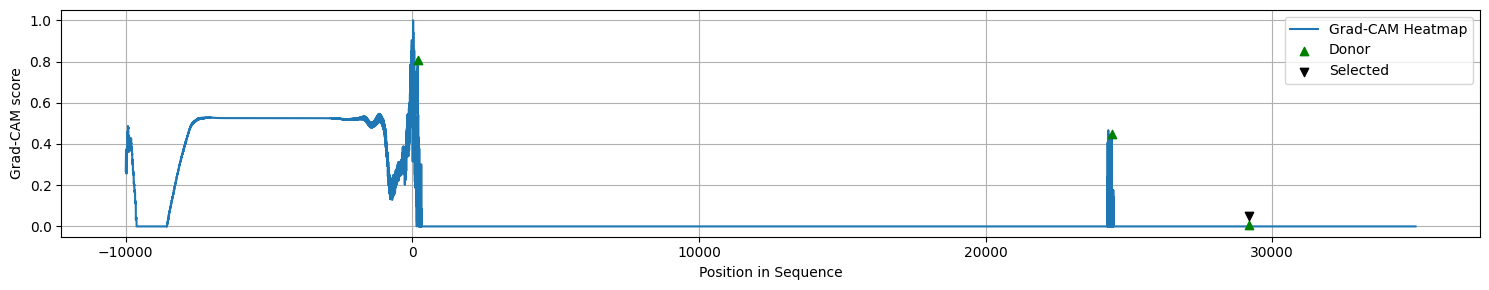

  8%|▊         | 3/38 [04:45<58:19, 99.97s/it]

Transcript spans: 5000 to 44999
24290


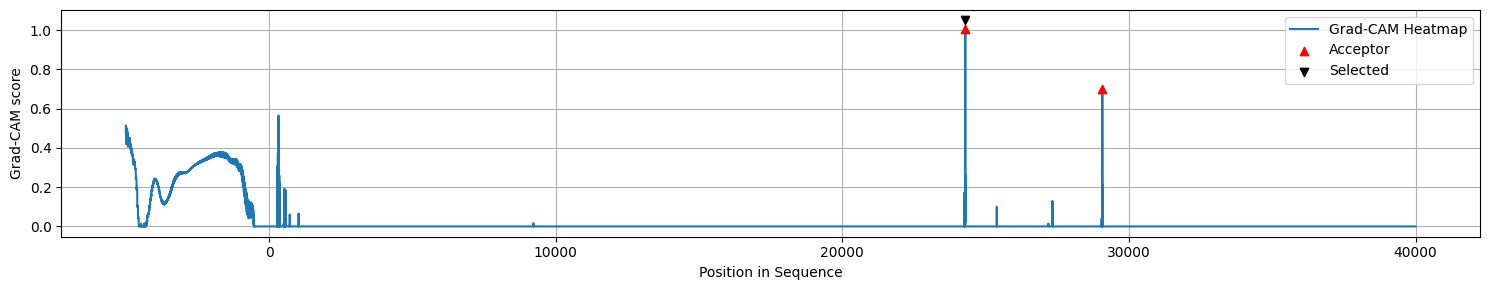

29071


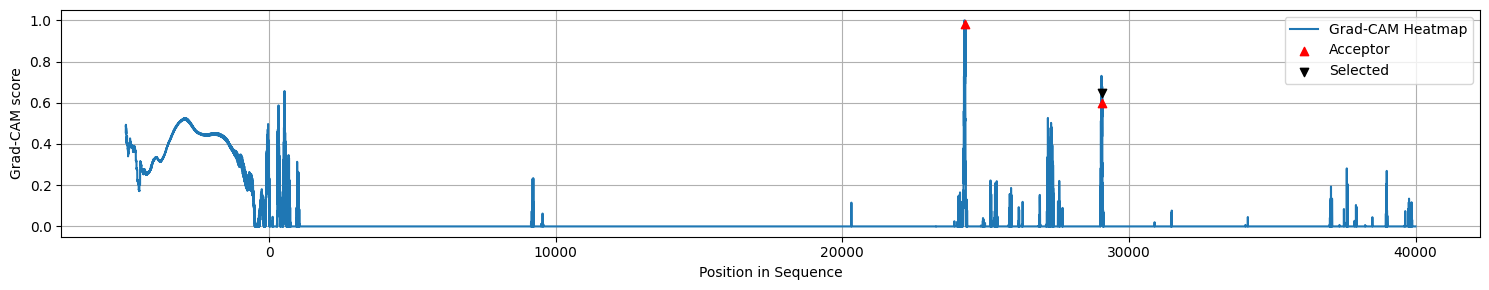

184


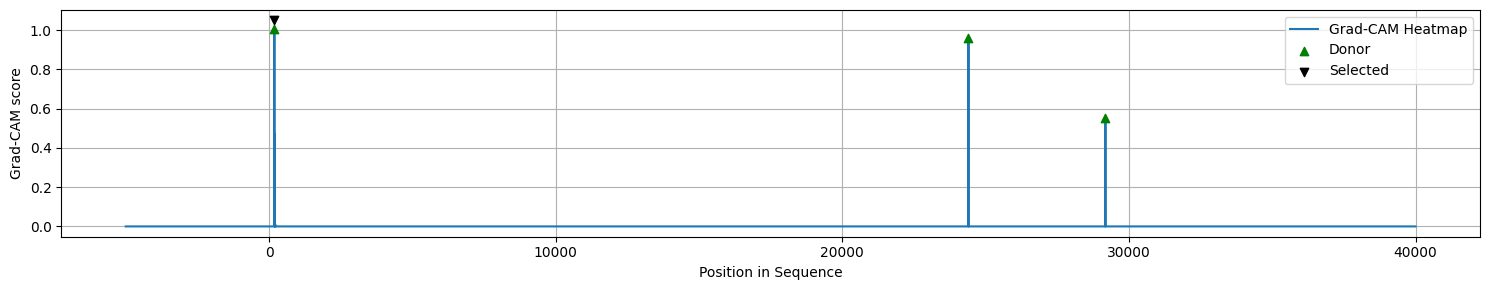

24400


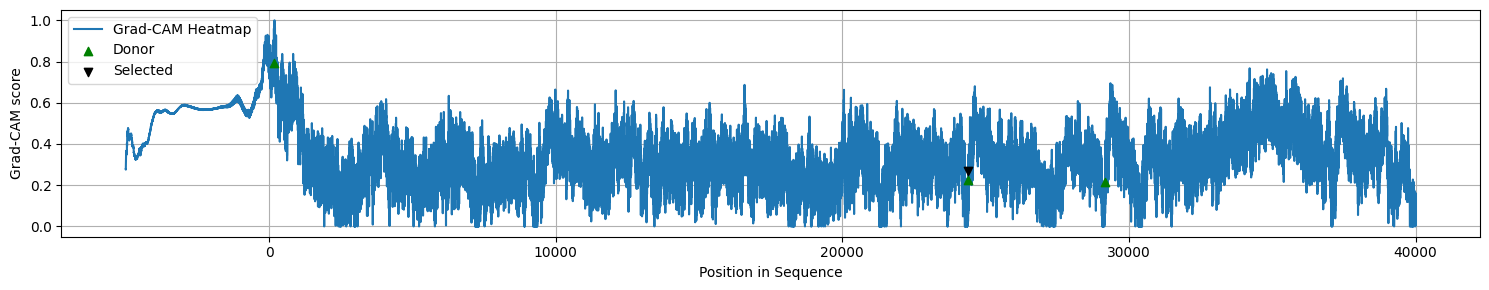

29179


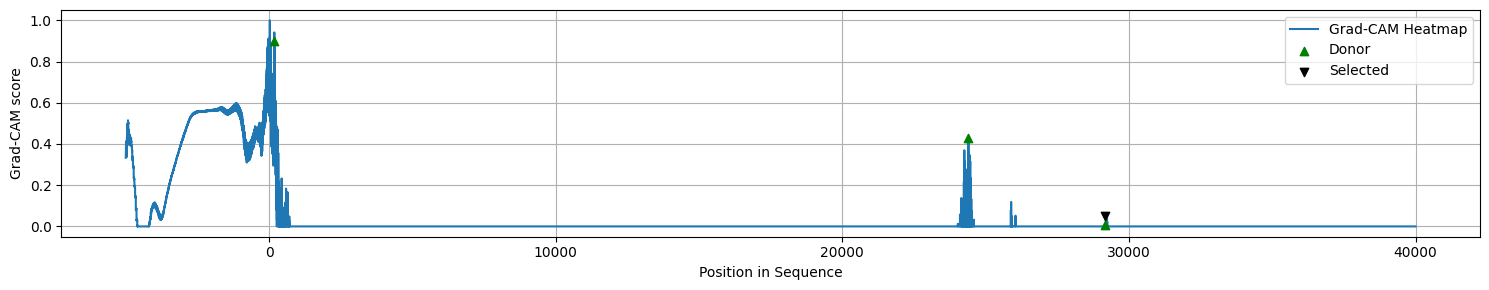

 11%|█         | 4/38 [06:36<59:06, 104.32s/it]

Transcript spans: 0 to 44999
24290


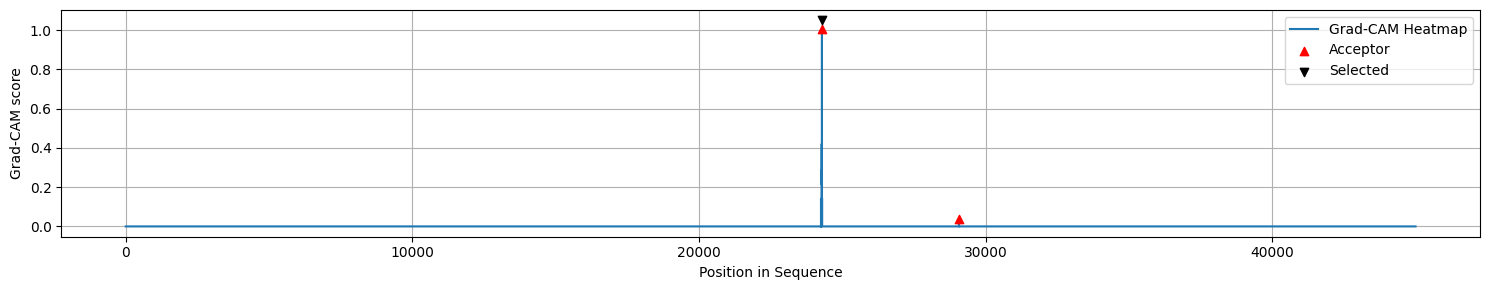

29071


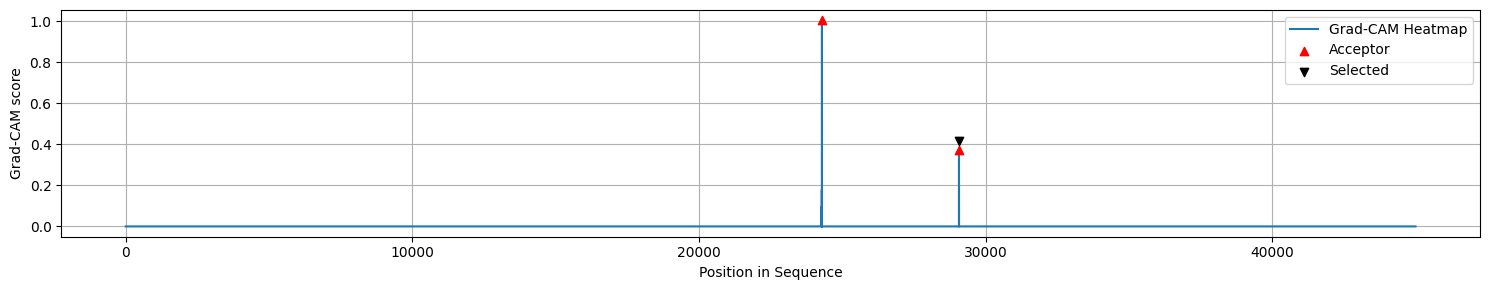

184


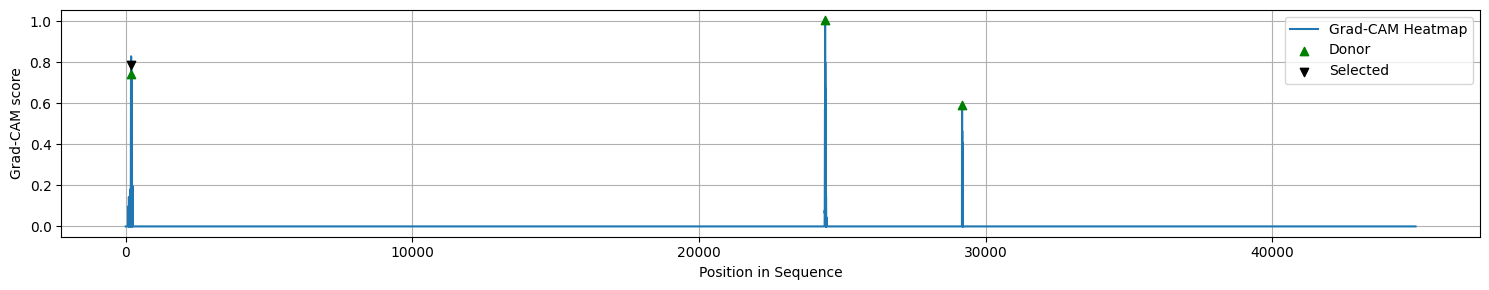

24400


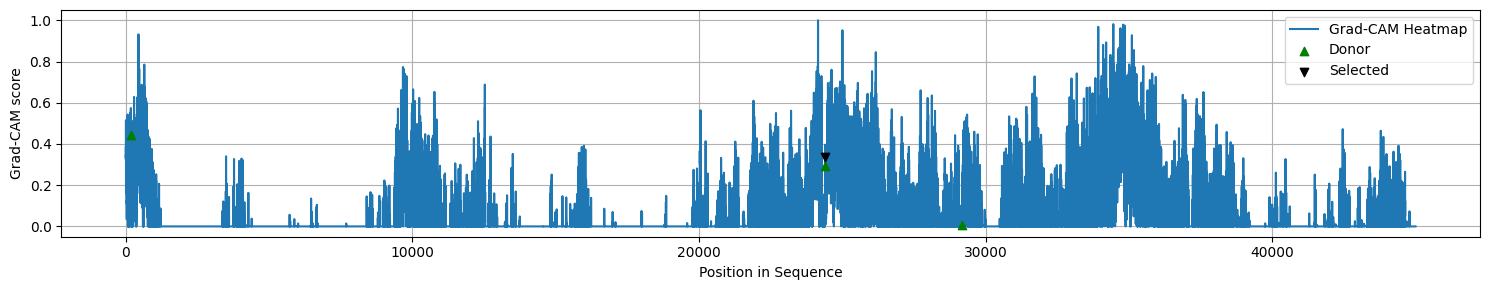

29179


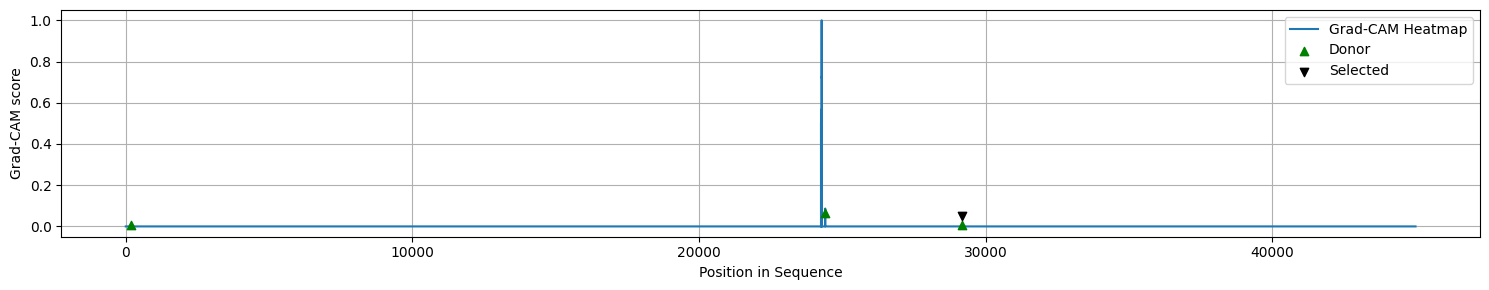

 13%|█▎        | 5/38 [08:27<58:39, 106.66s/it]

Transcript spans: 0 to 44999
24290


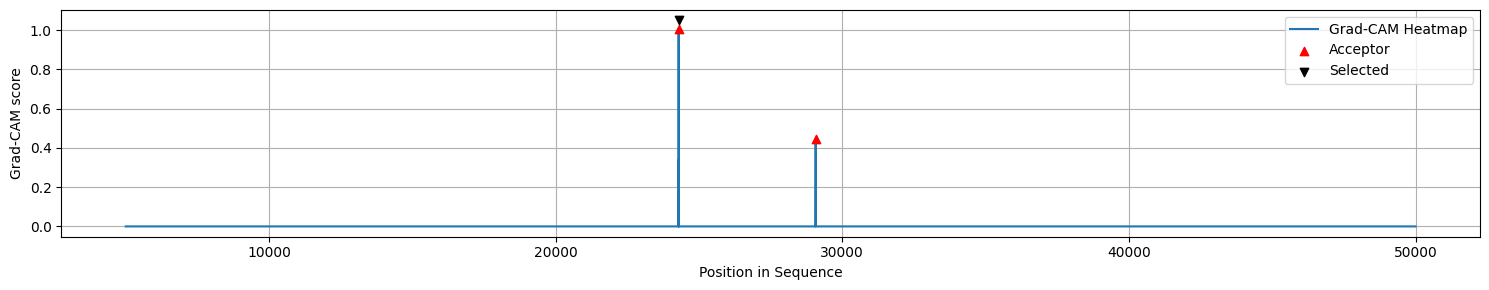

29071


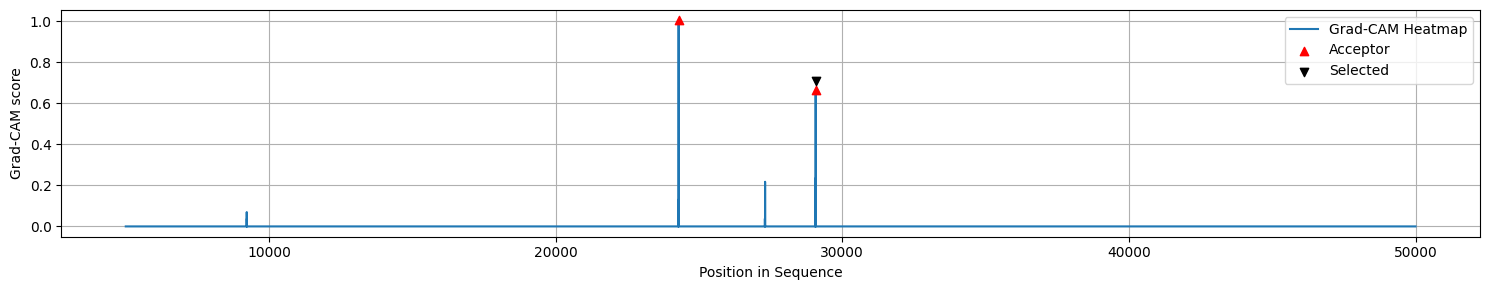

24400


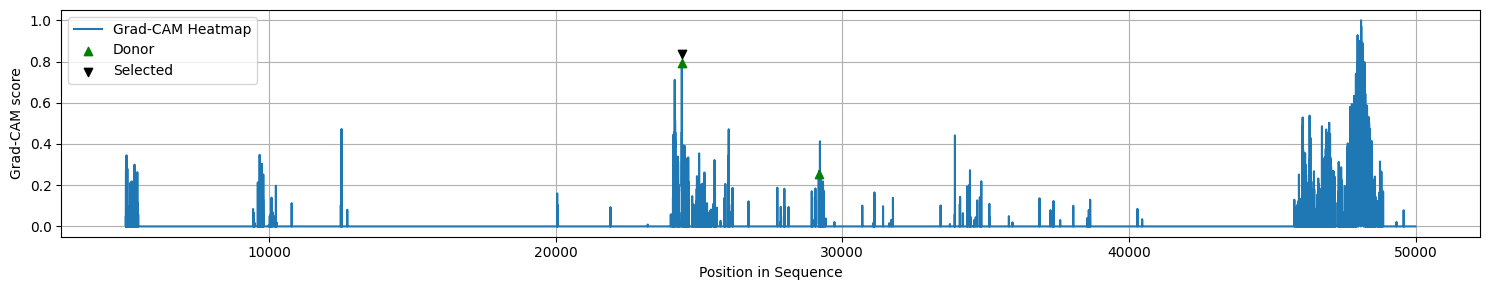

29179


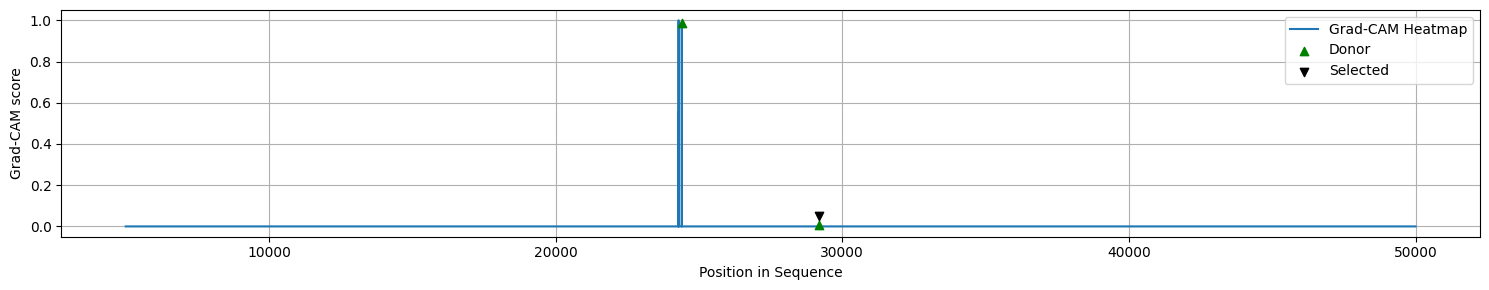

 16%|█▌        | 6/38 [09:55<53:35, 100.49s/it]

Transcript spans: 0 to 44999
24290


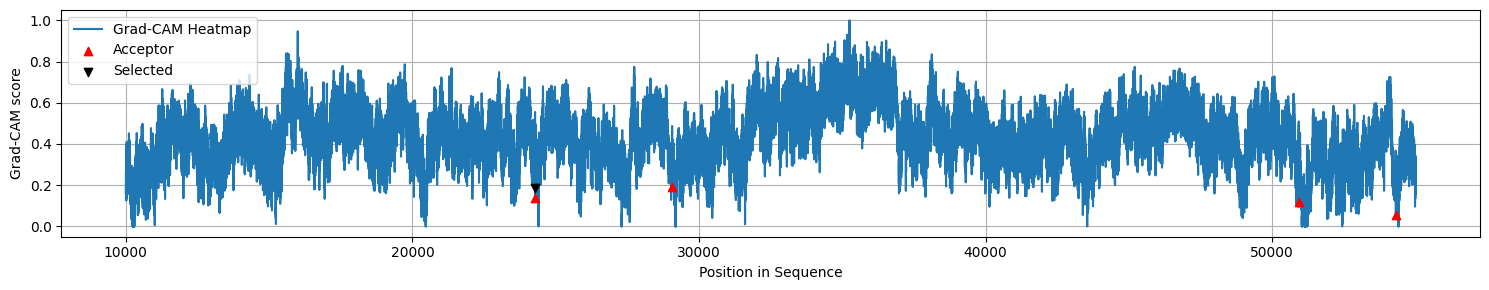

29071


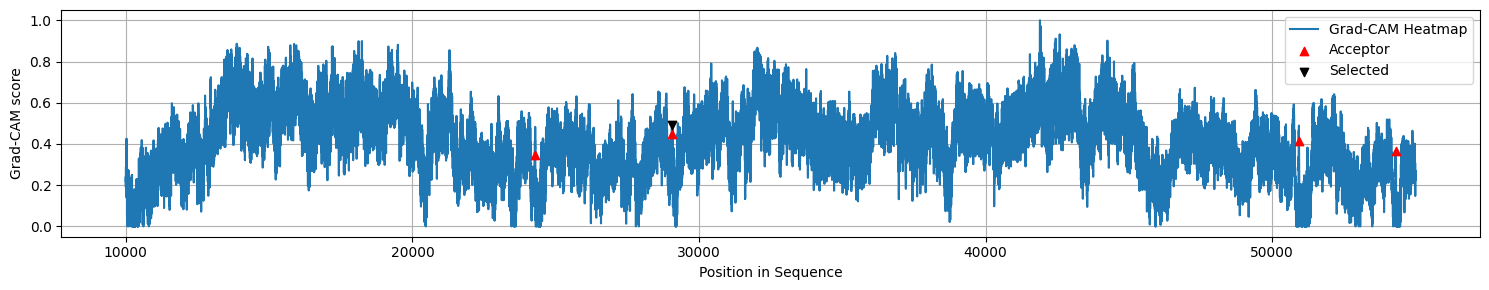

50936


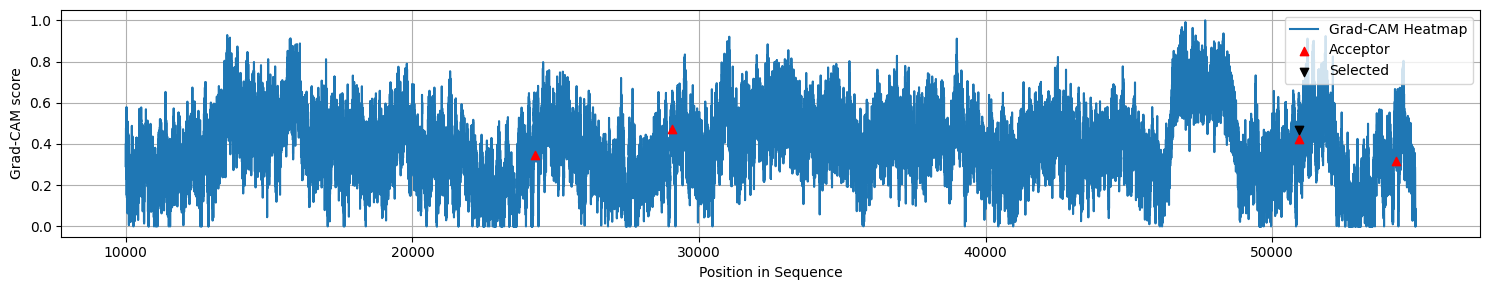

54313


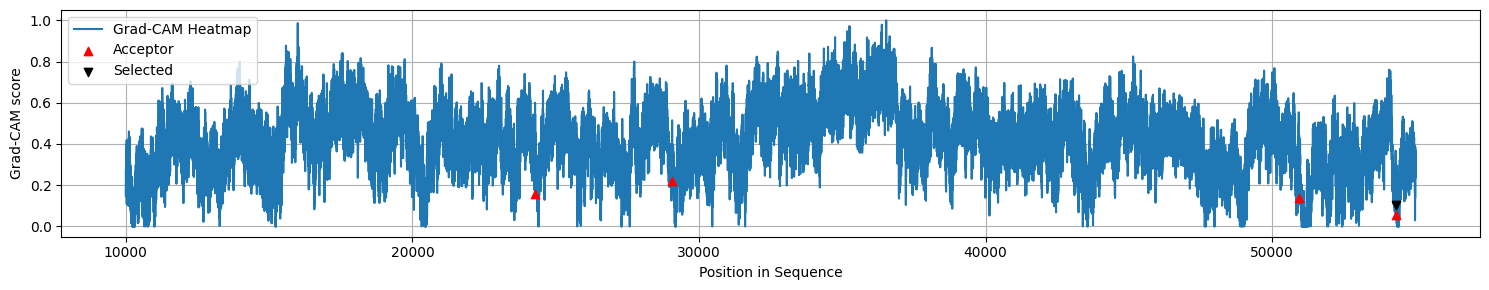

24400


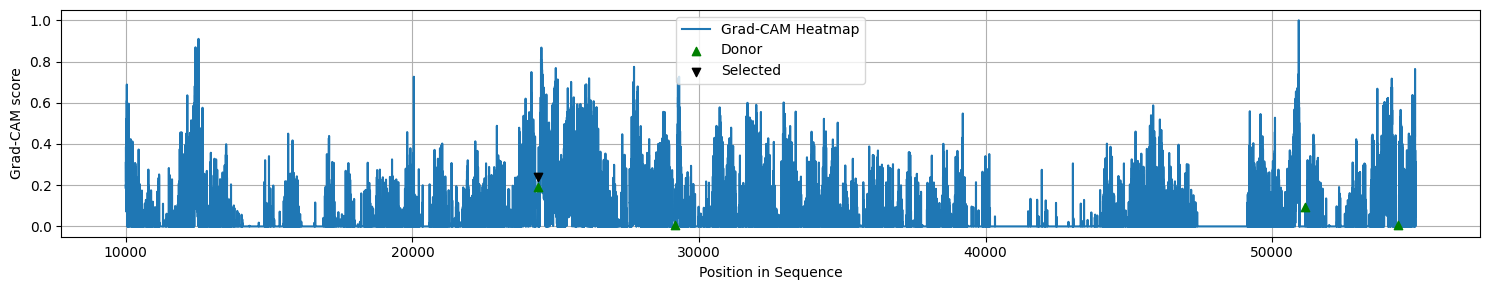

29179


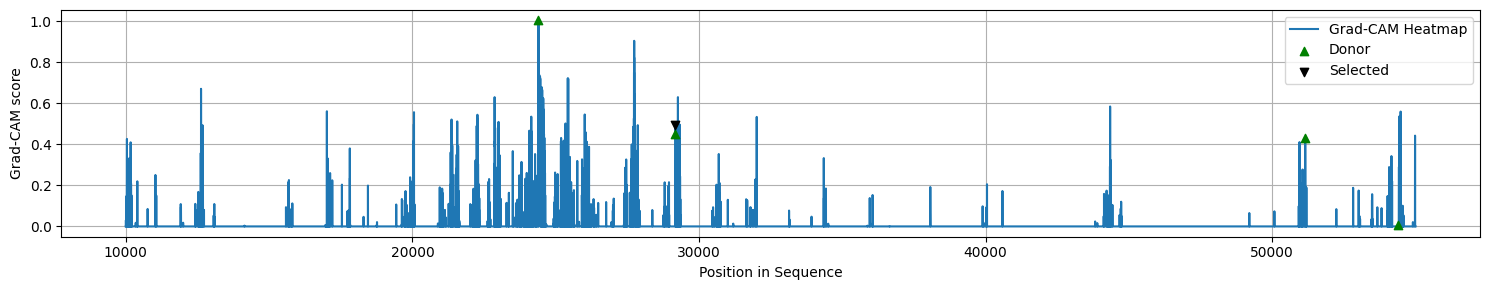

51151


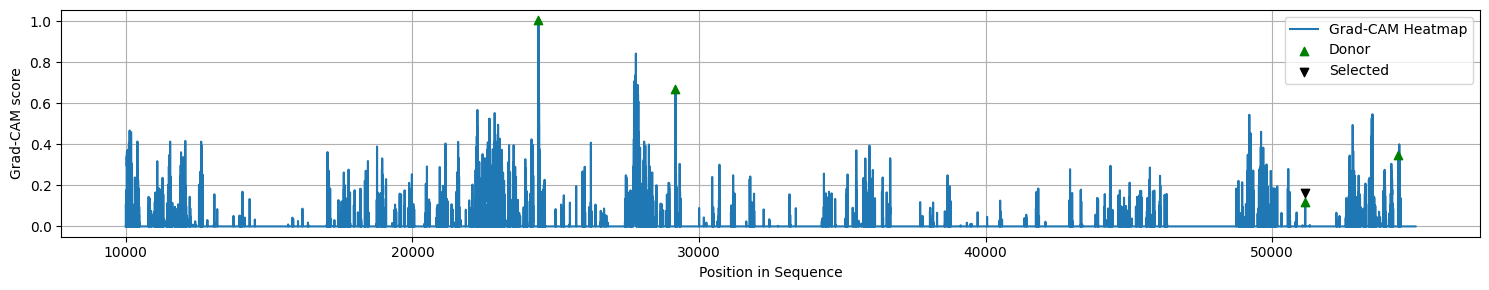

54402


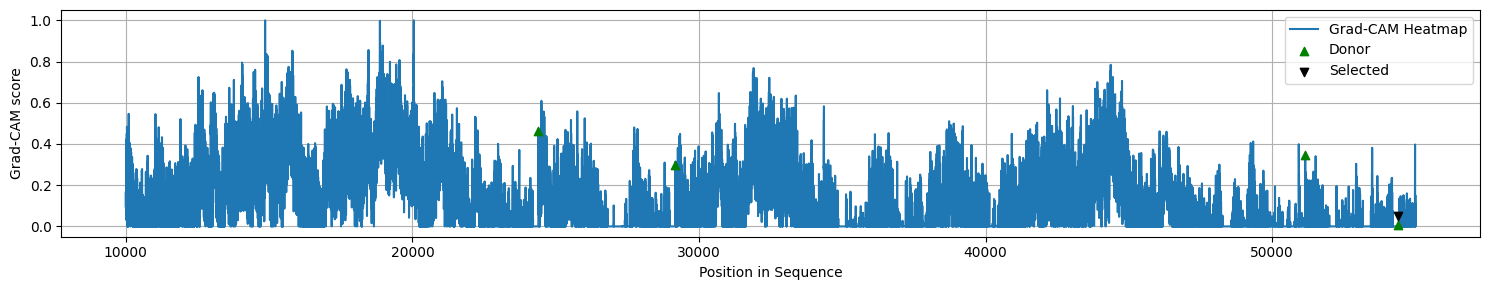

 18%|█▊        | 7/38 [12:52<1:04:49, 125.46s/it]

Transcript spans: 0 to 44999
24290


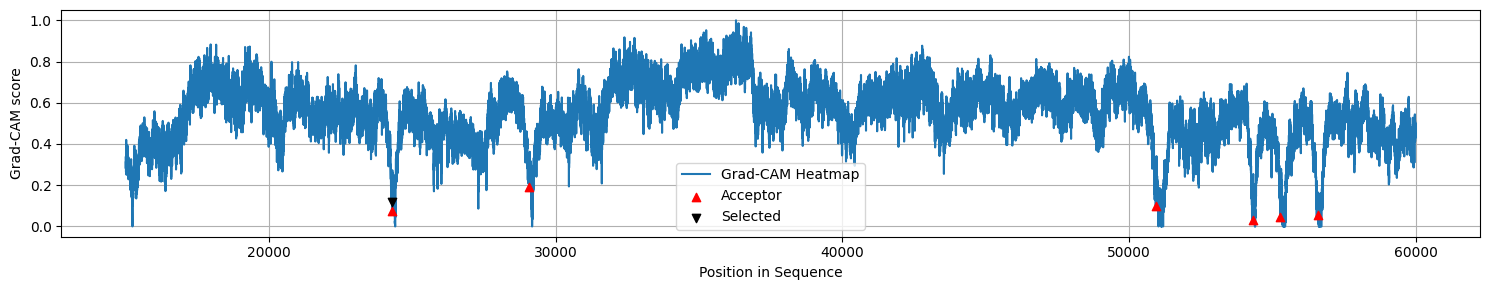

29071


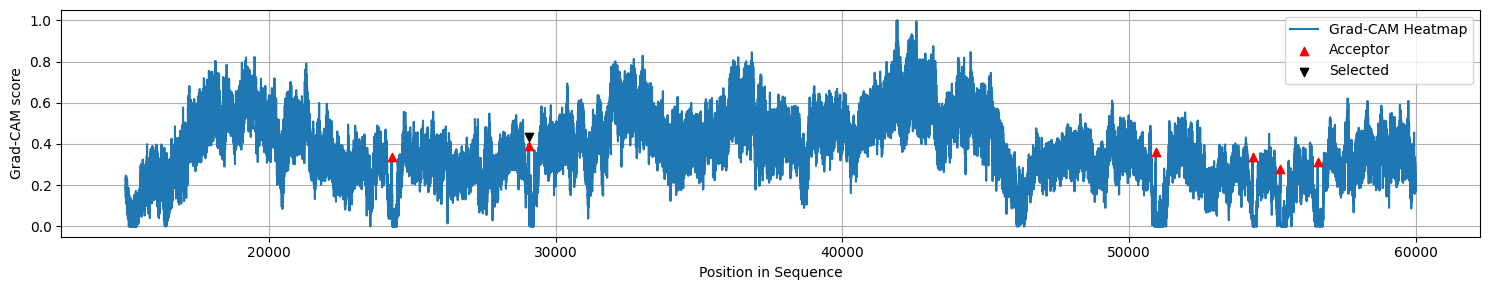

50936


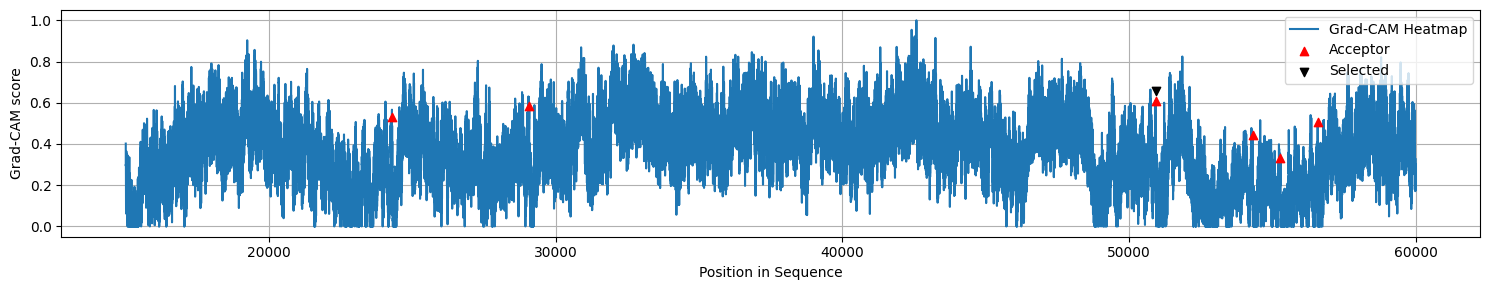

54313


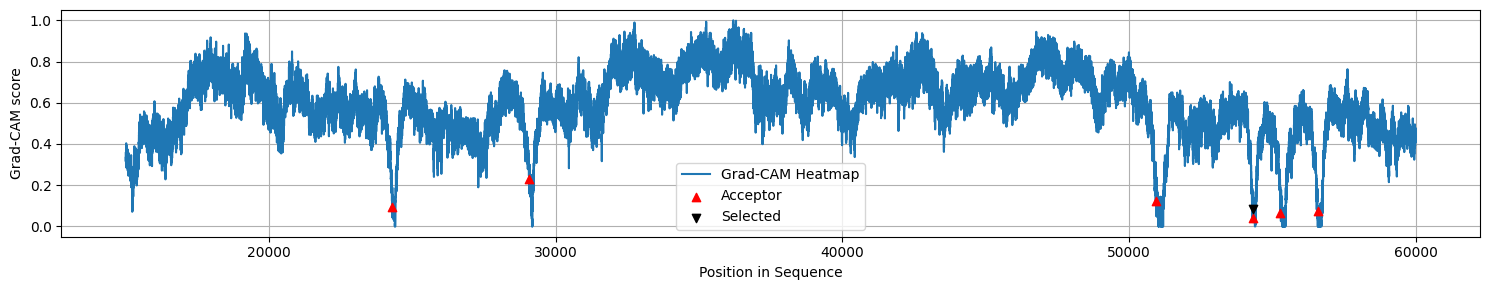

55285


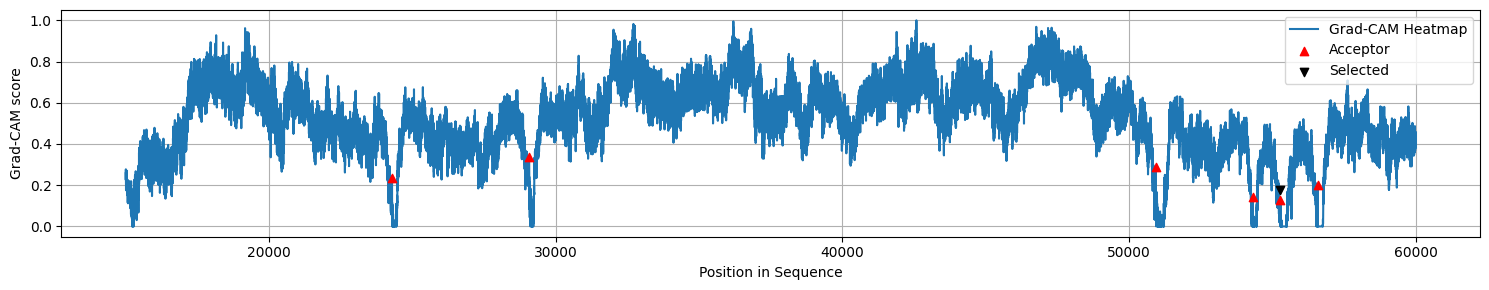

56585


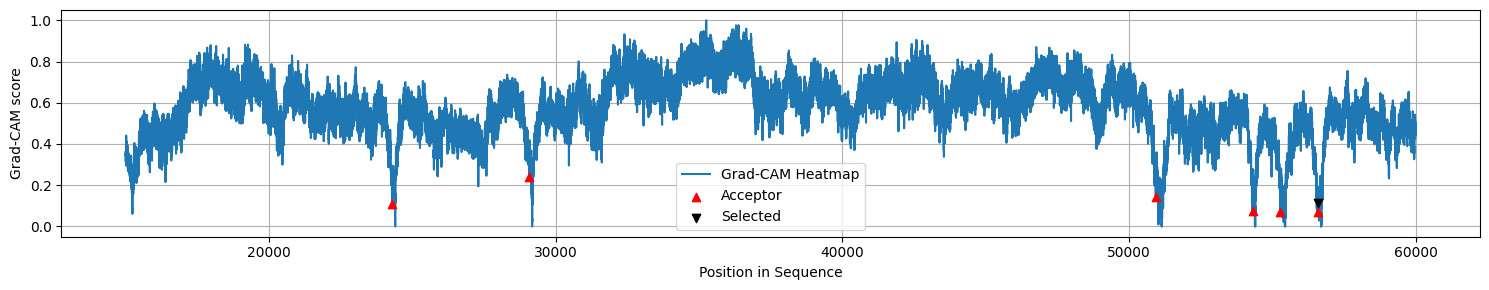

24400


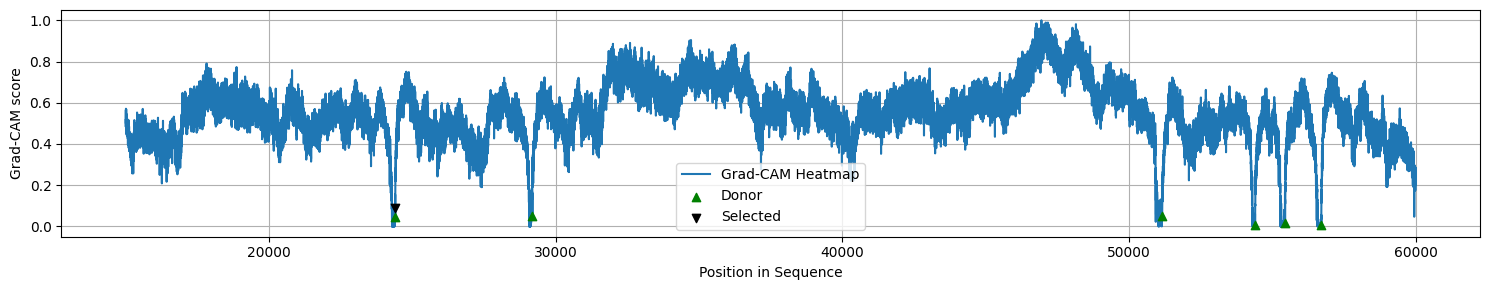

29179


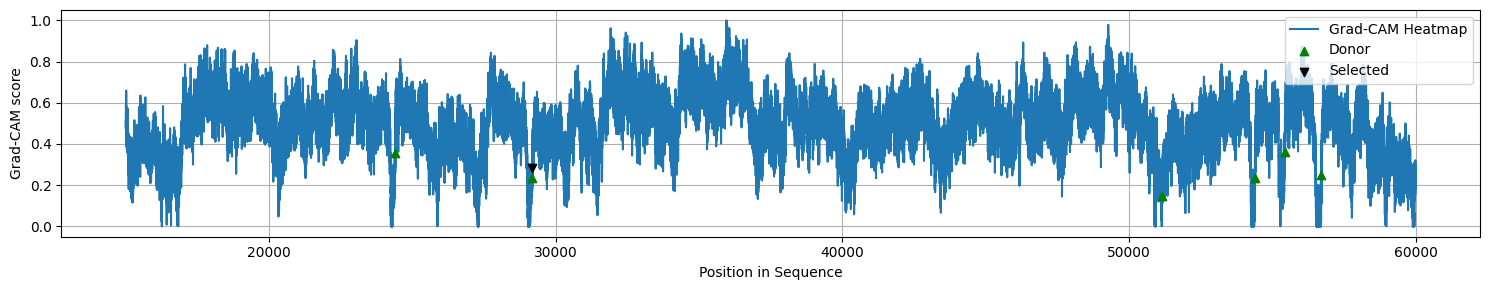

51151


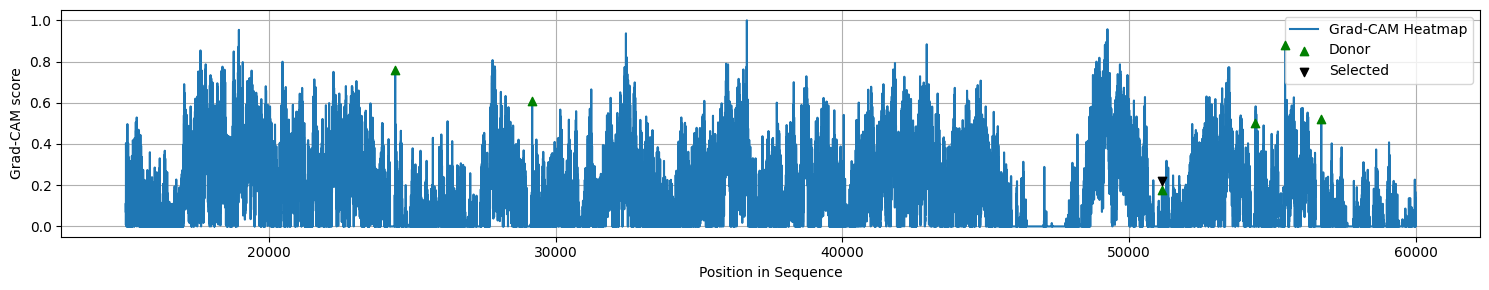

54402


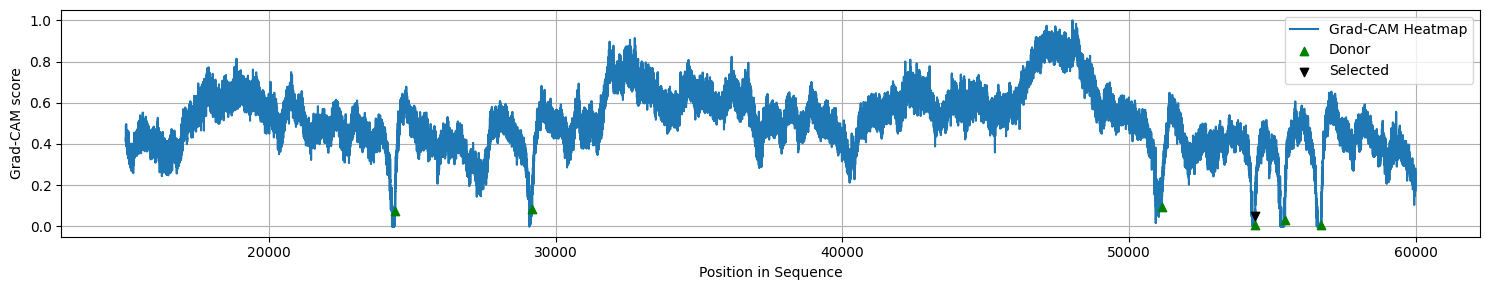

55448


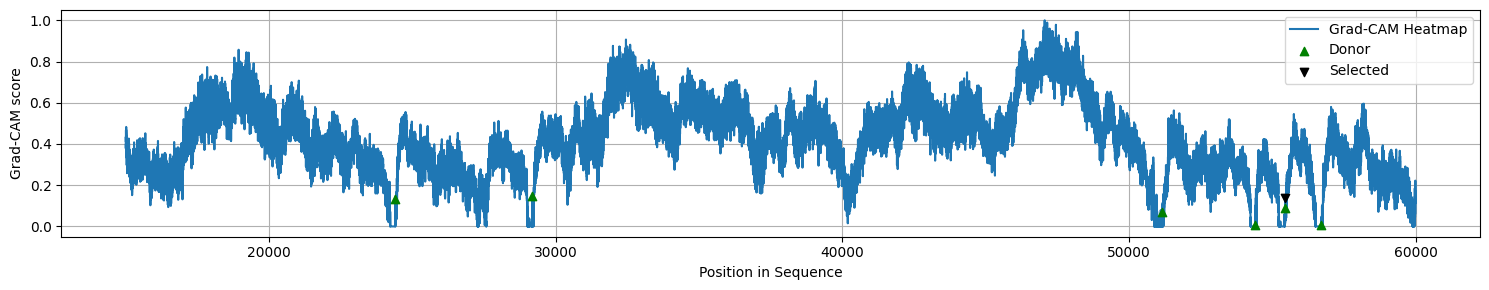

56710


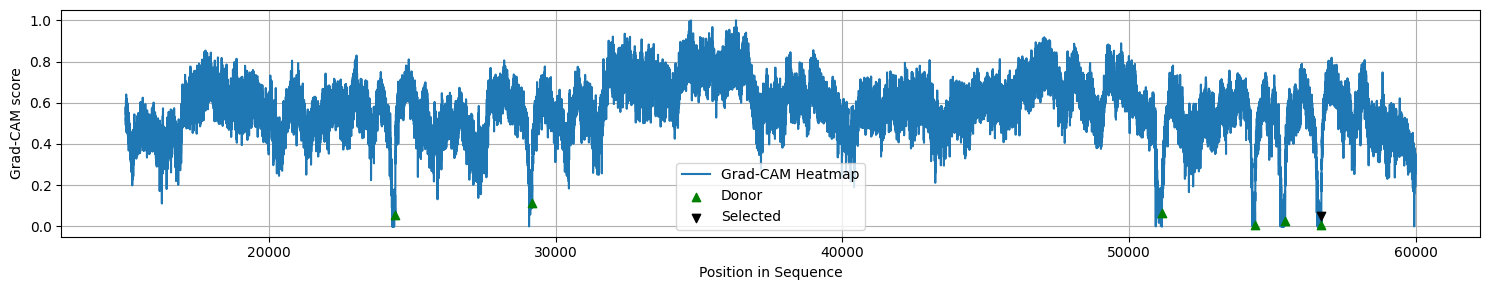

 21%|██        | 8/38 [17:18<1:25:06, 170.22s/it]

Transcript spans: 0 to 44999
24290


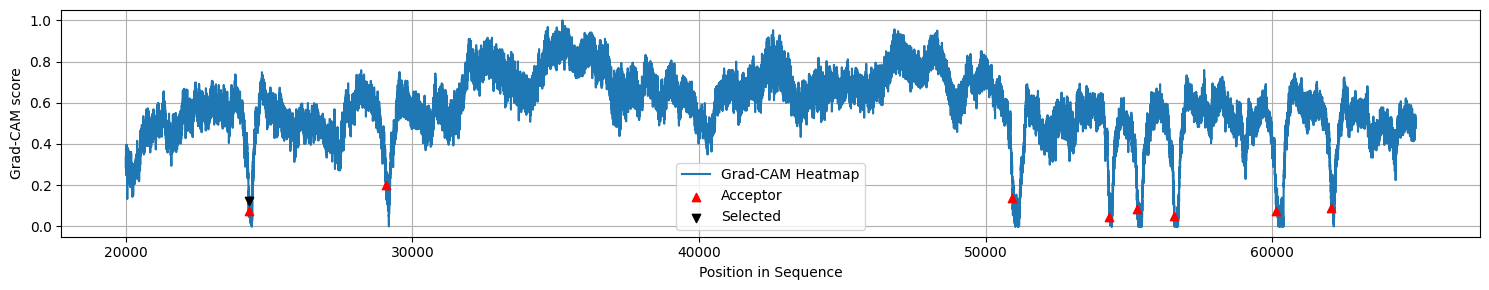

29071


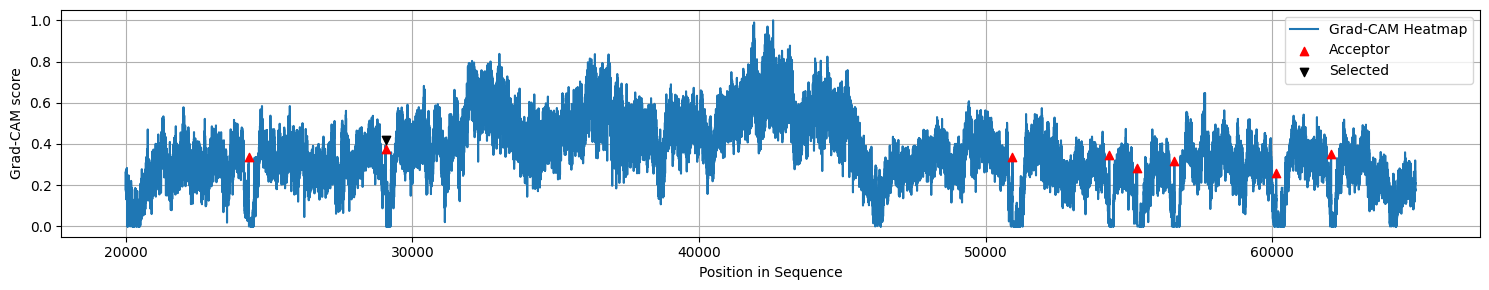

50936


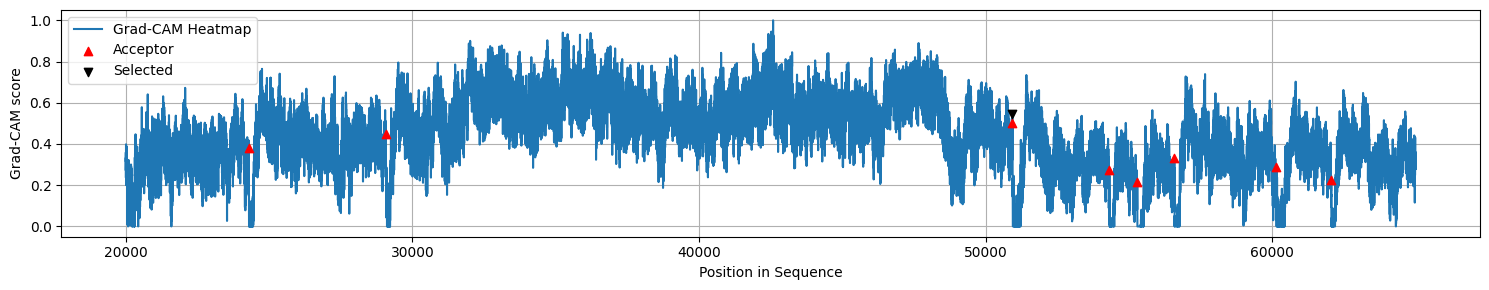

54313


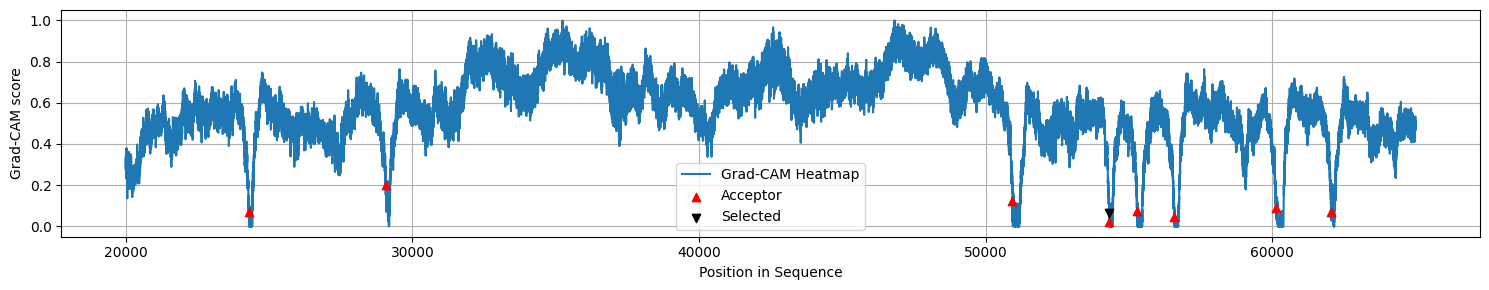

55285


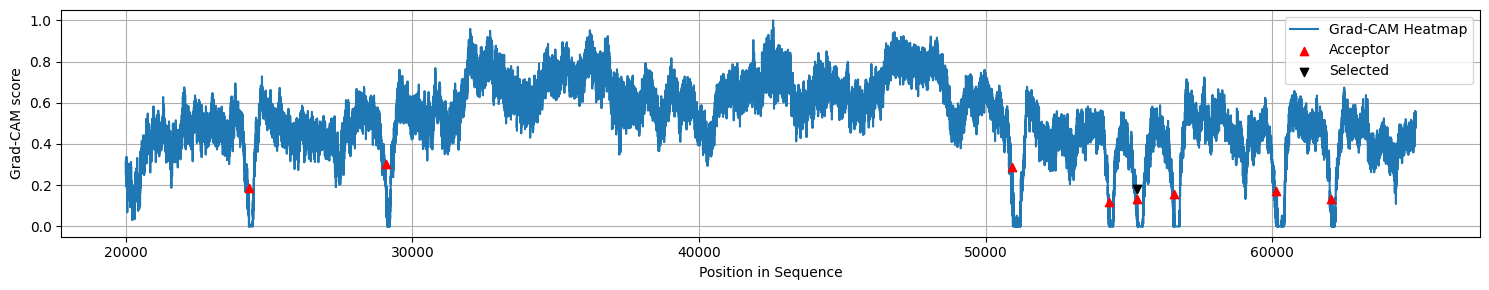

56585


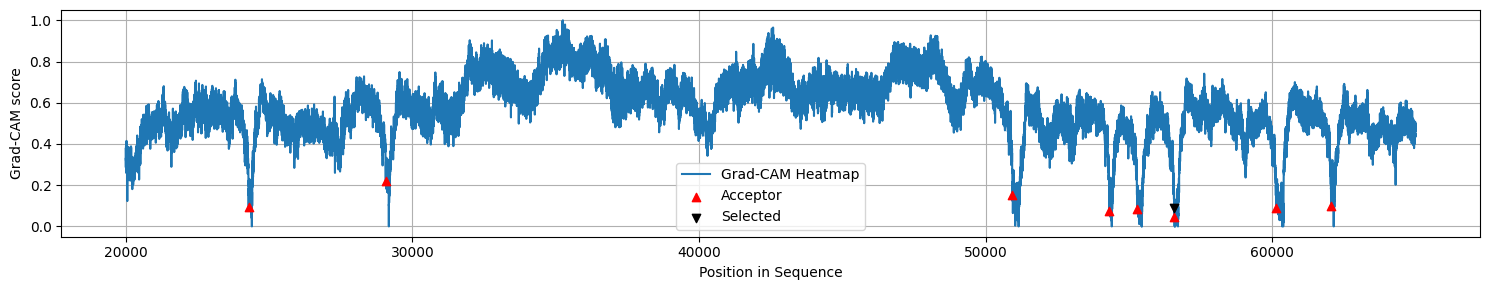

60137


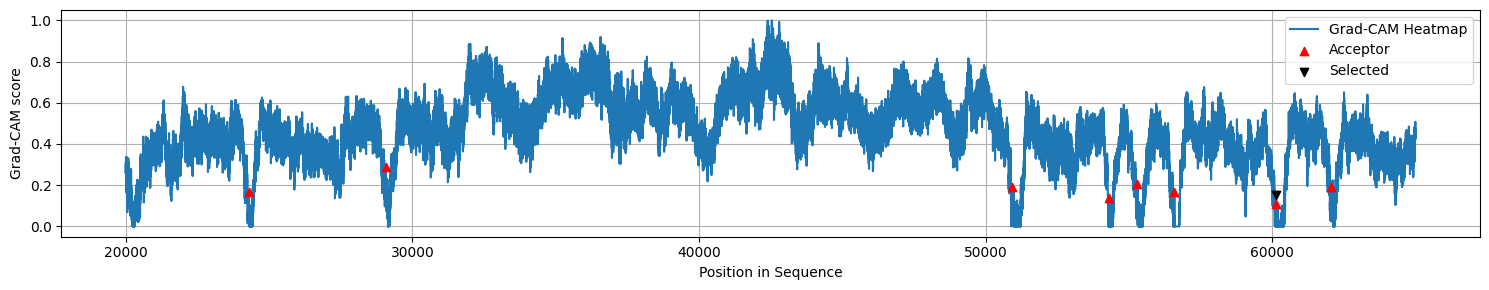

62053


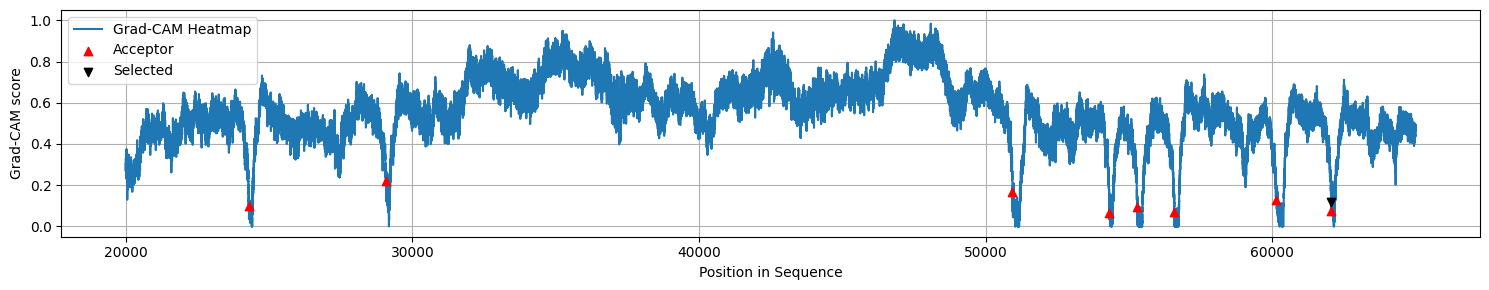

24400


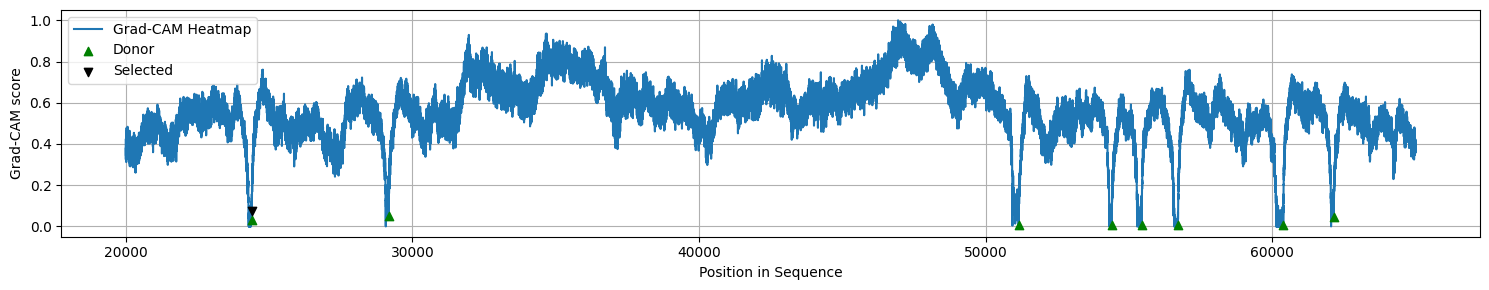

29179


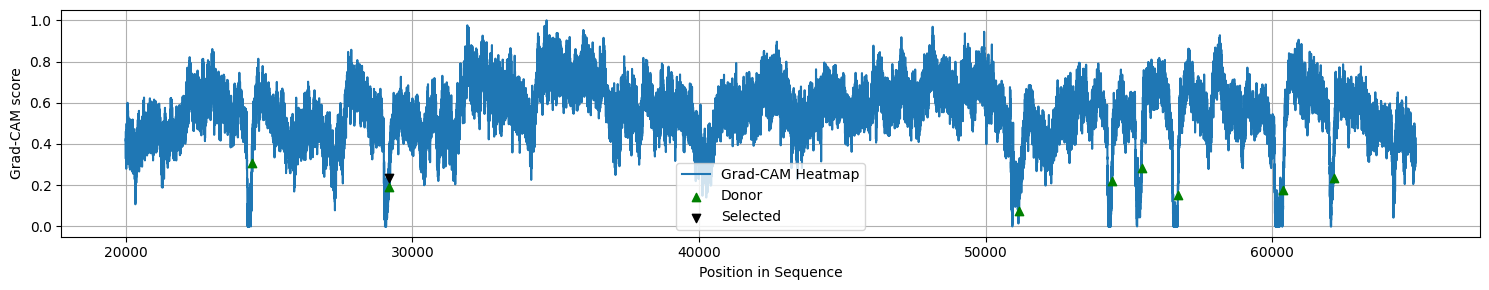

51151


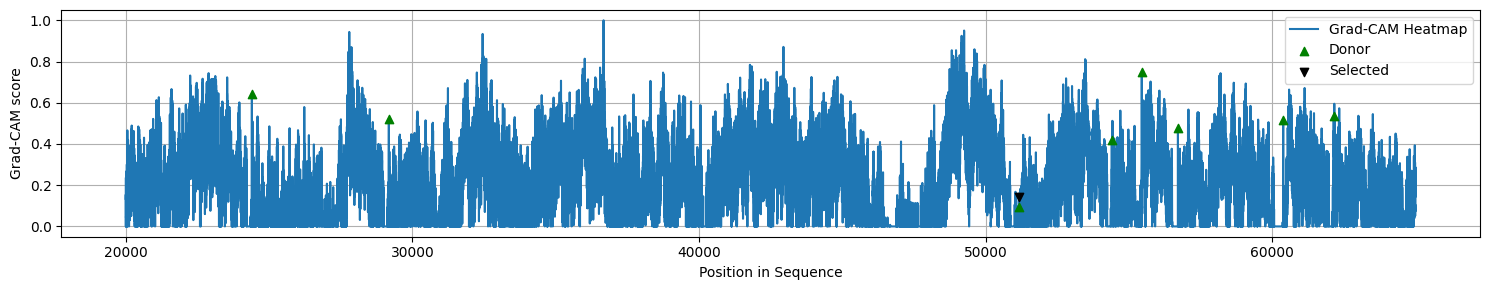

54402


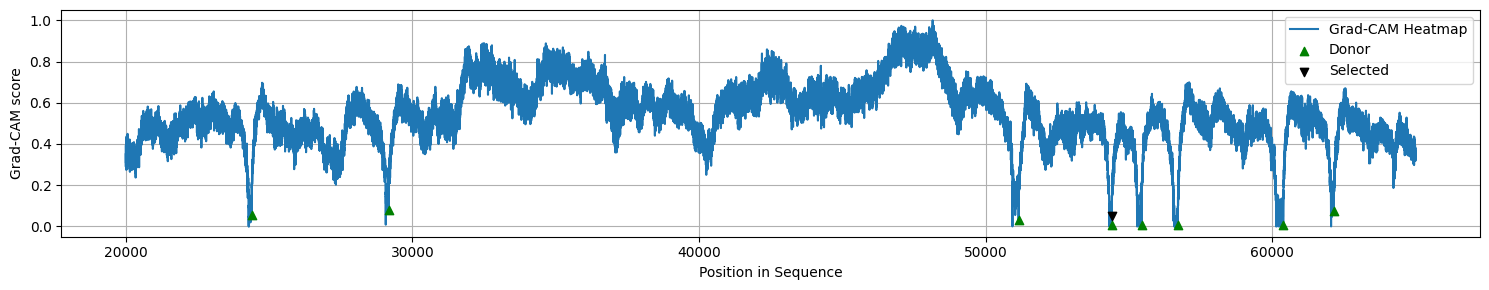

55448


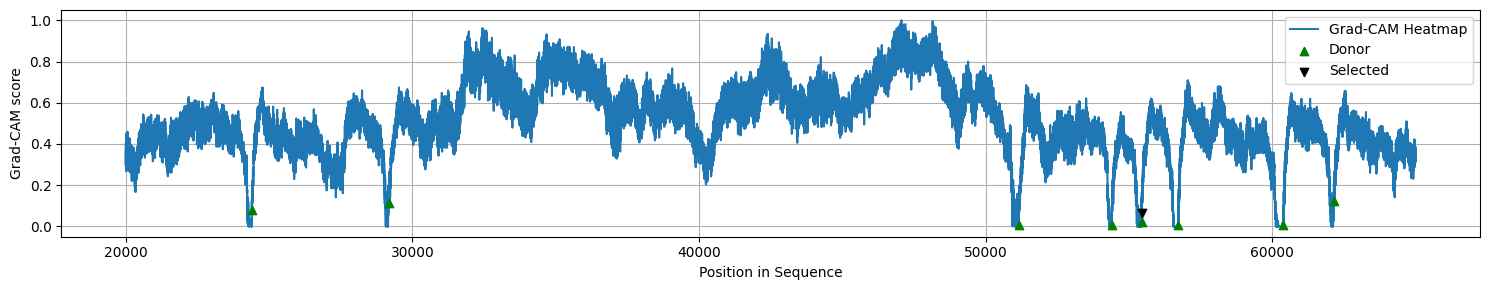

56710


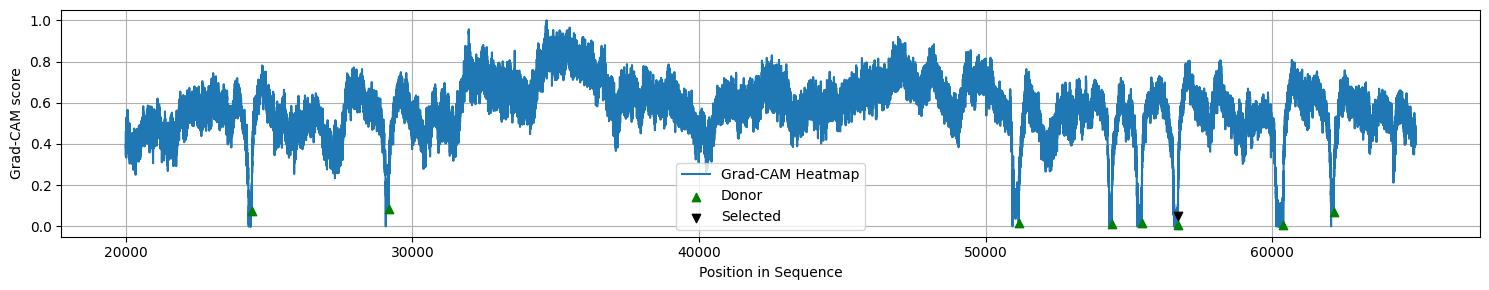

60383


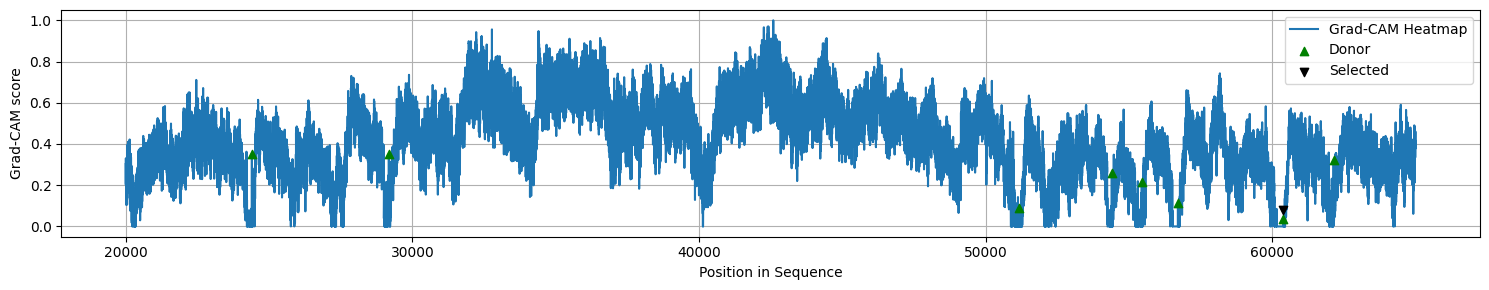

62145


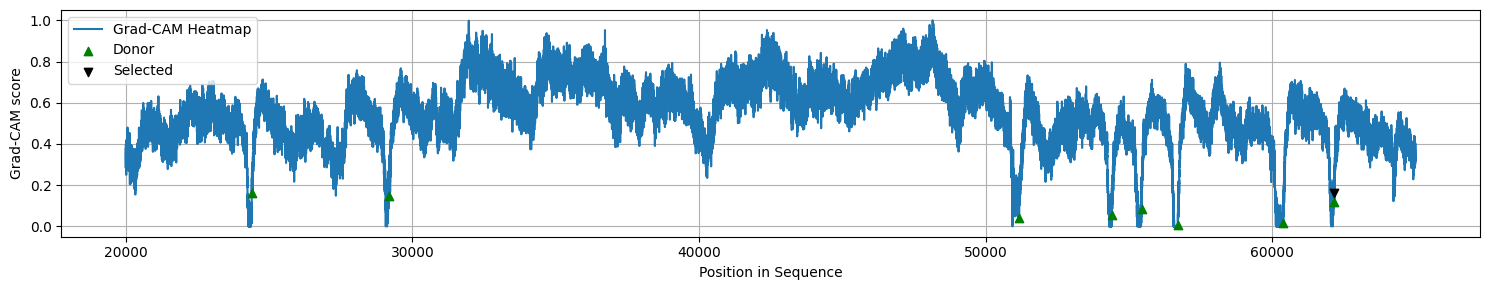

 24%|██▎       | 9/38 [23:14<1:50:17, 228.17s/it]

Transcript spans: 0 to 44999
29071


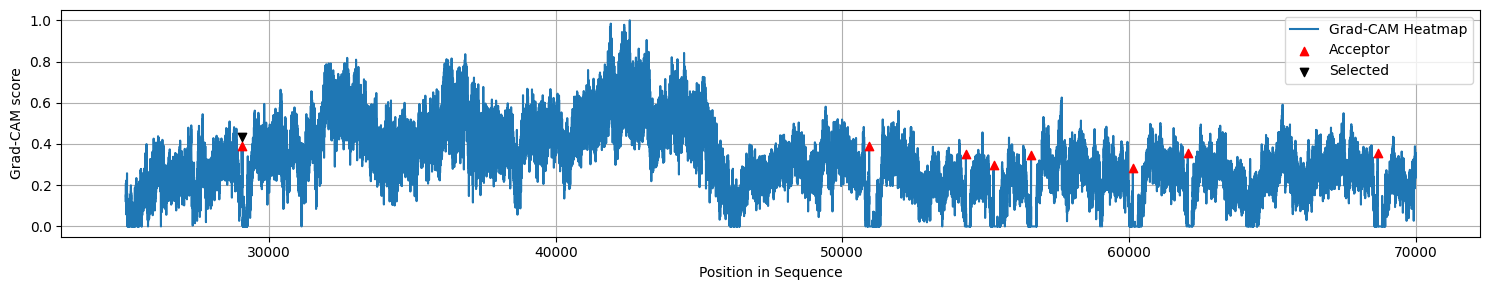

50936


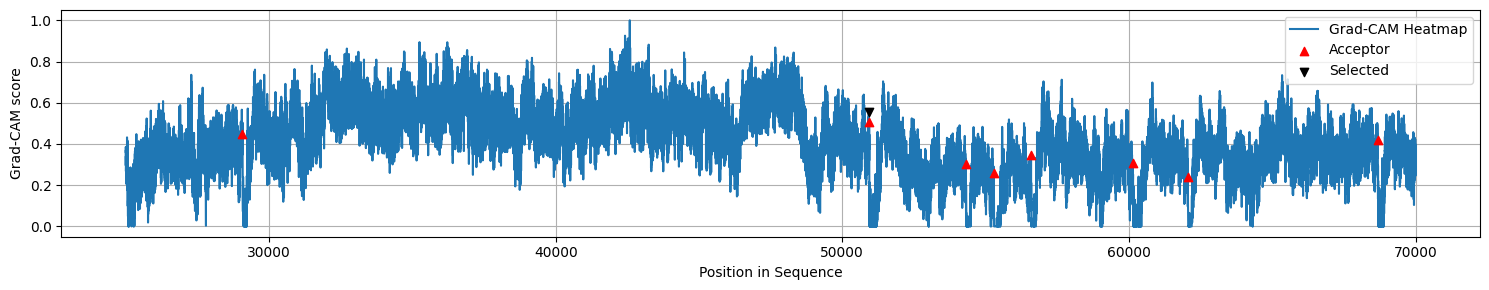

54313


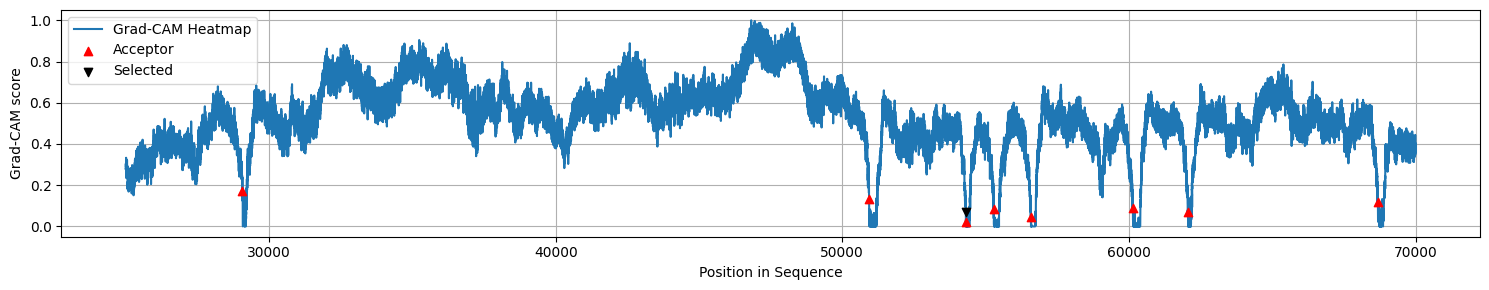

55285


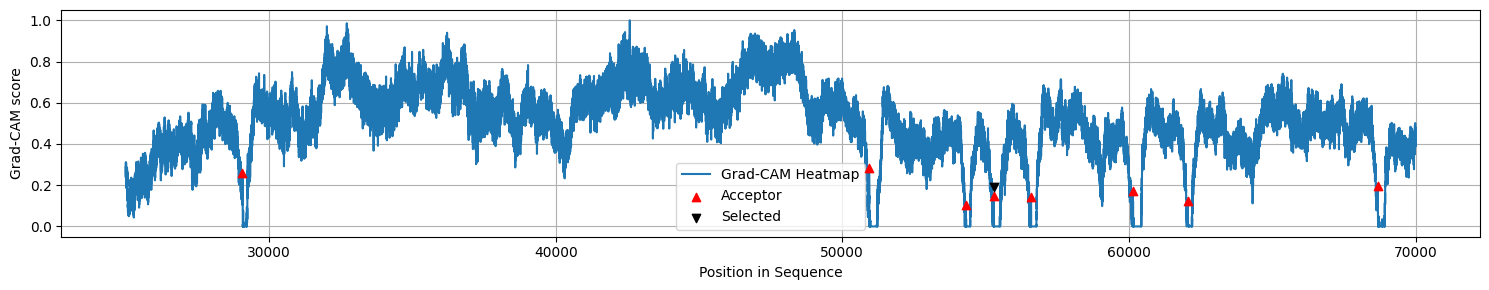

56585


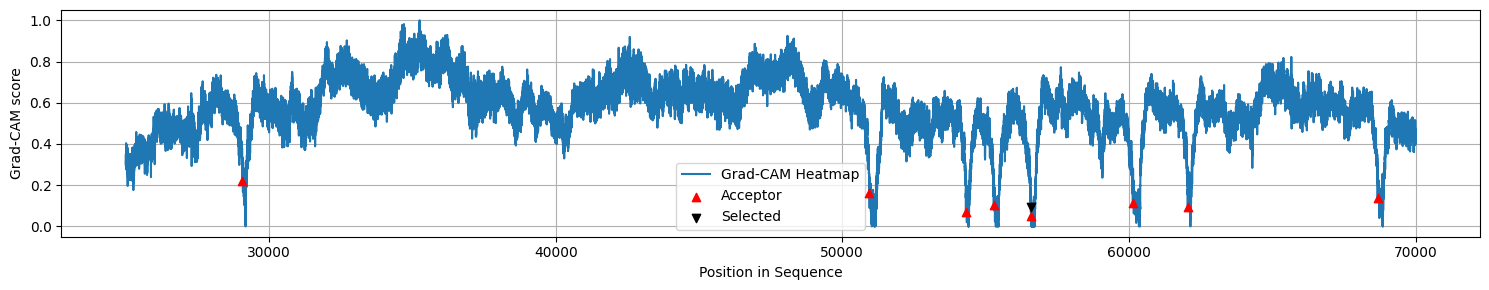

60137


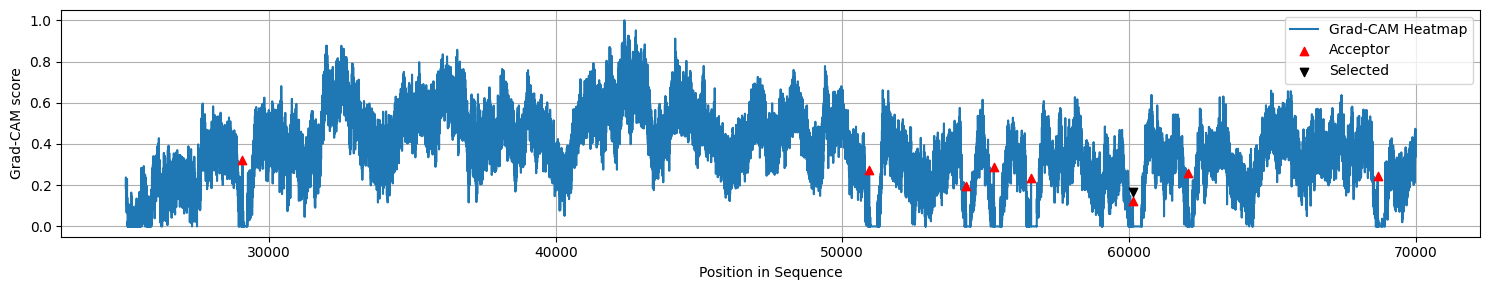

62053


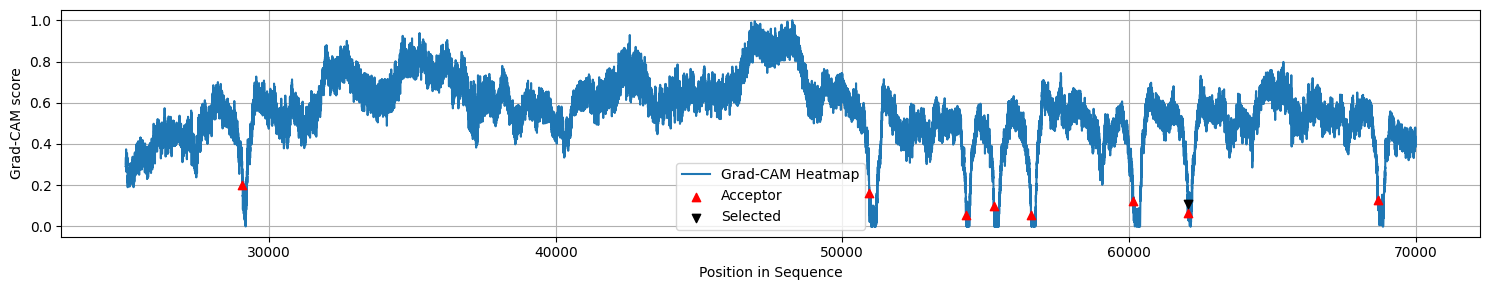

68678


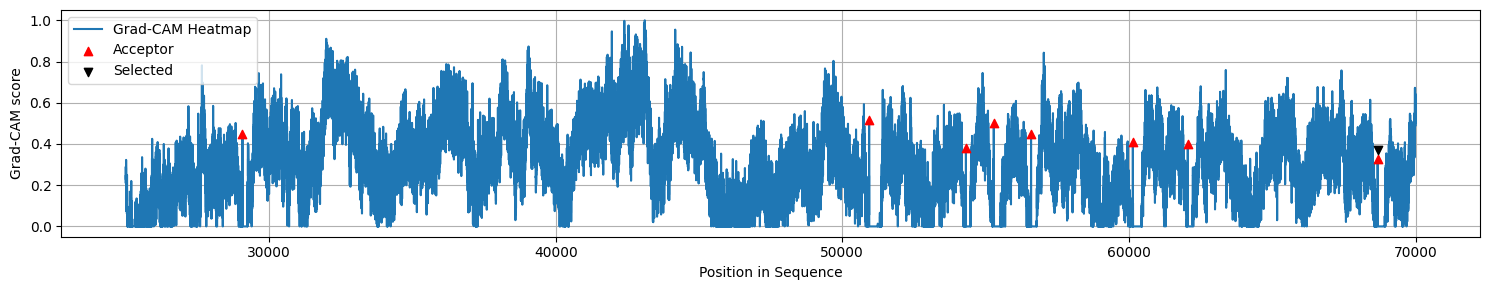

29179


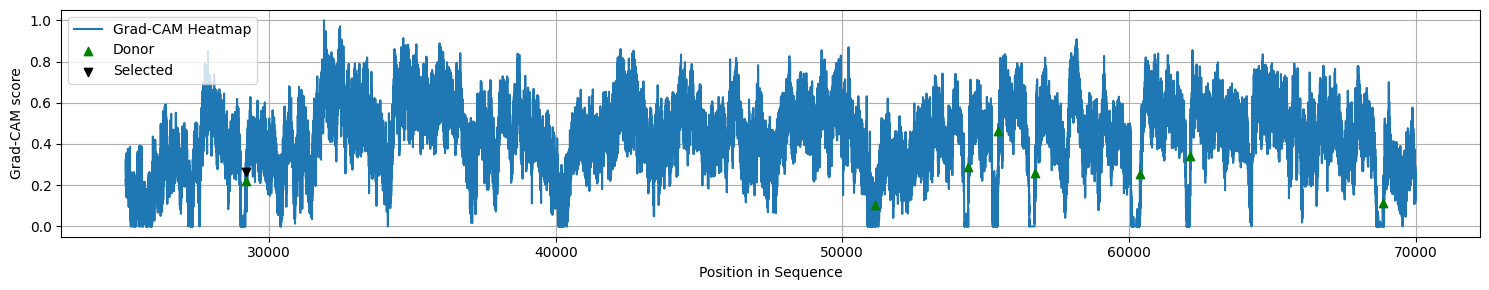

51151


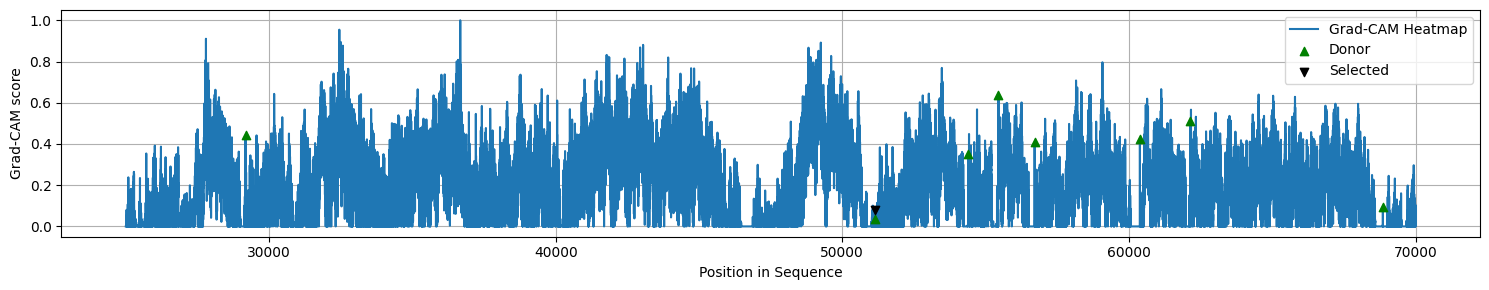

54402


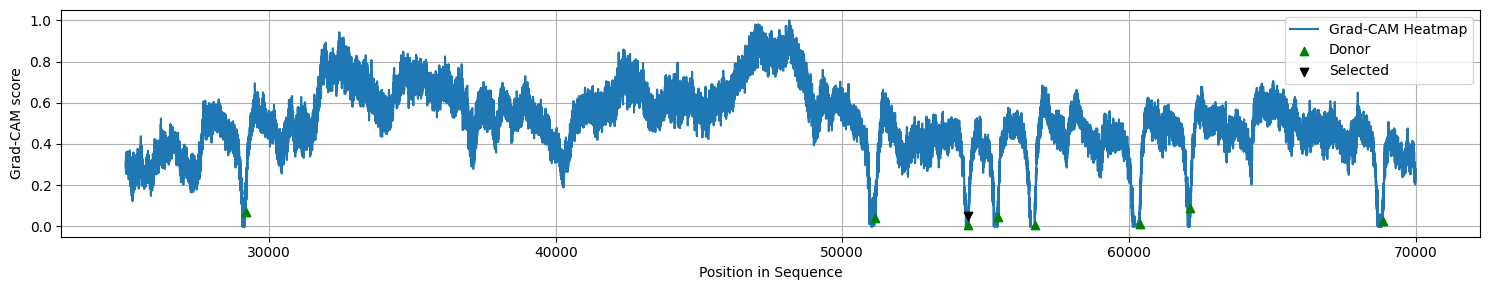

55448


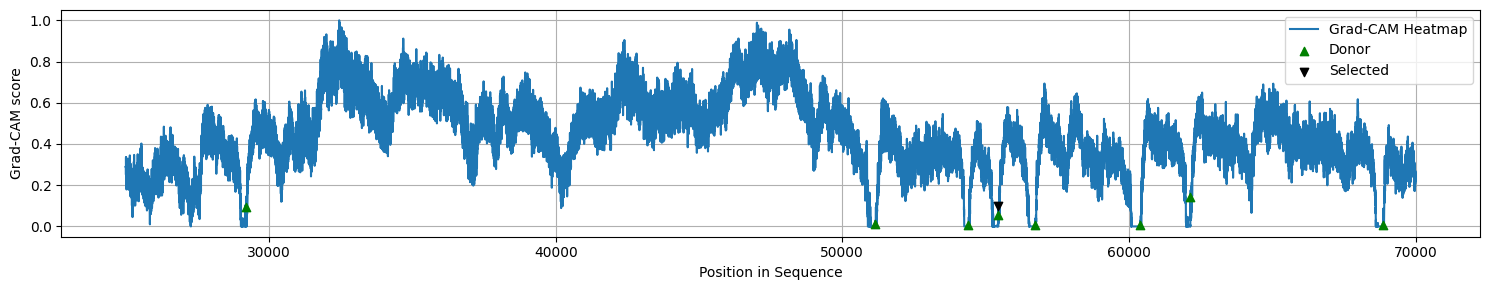

56710


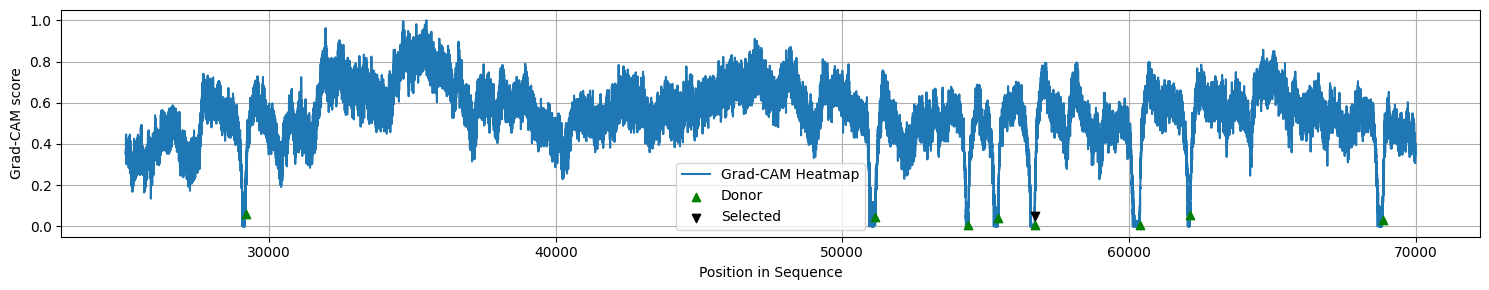

60383


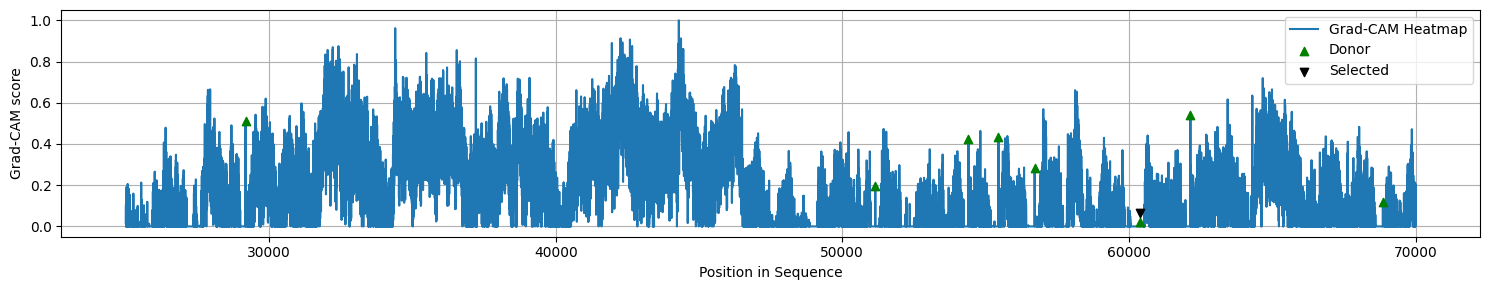

62145


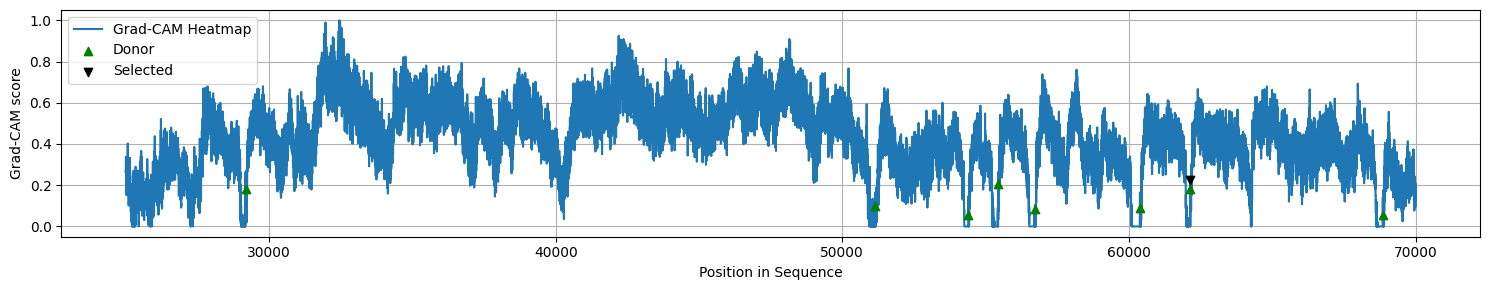

68860


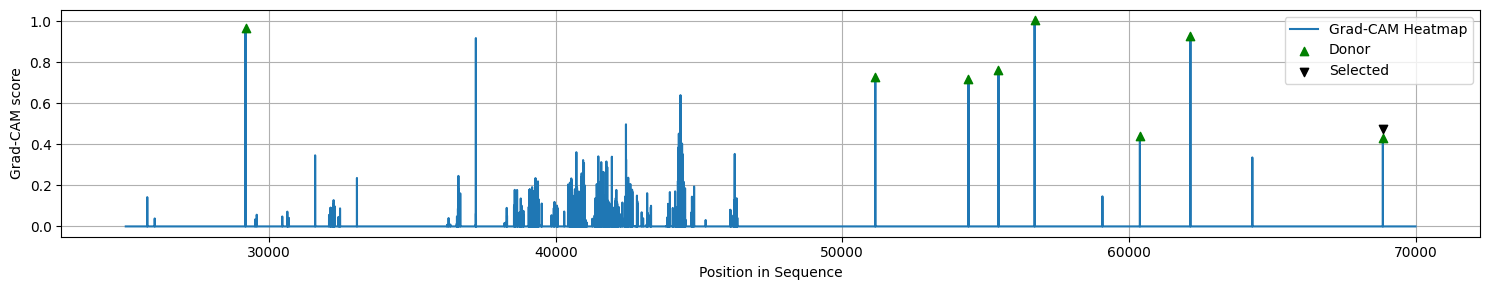

 26%|██▋       | 10/38 [29:12<2:05:11, 268.26s/it]

Transcript spans: 0 to 44999


 26%|██▋       | 10/38 [31:16<1:27:33, 187.61s/it]


KeyboardInterrupt: 

In [20]:
test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    batch_features = batch_chunks.to(torch.float32).to(device)      # shape: [1, 4, 45000]
    targets = torch.squeeze(target_chunks.to(torch.float32).to(device), dim=0)  # shape: [3, 45000]
    
    signal = batch_features[0].sum(dim=0)  # shape: [45000]
    nonzero_positions = torch.nonzero(signal > 0).squeeze()
    print("Transcript spans:", nonzero_positions.min().item(), "to", nonzero_positions.max().item())
    plot_GradCAM_full(models, batch_features, targets, i*5000)

   

24290


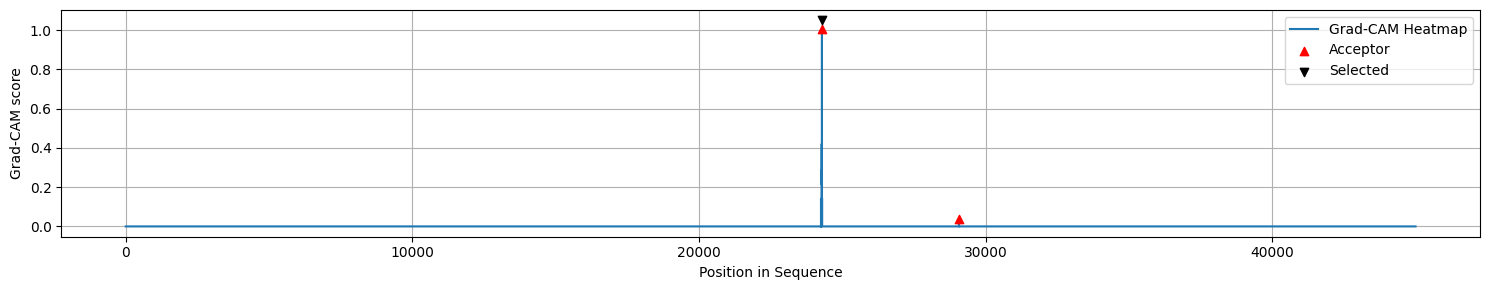

29071


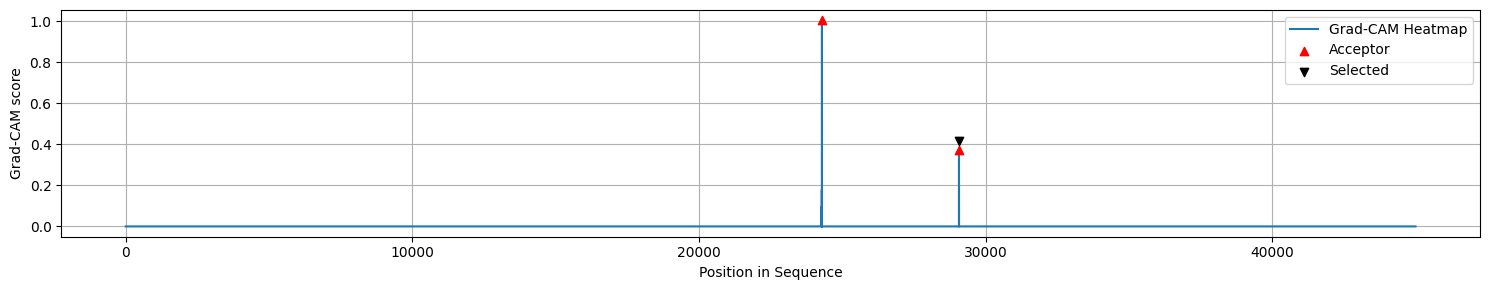

184


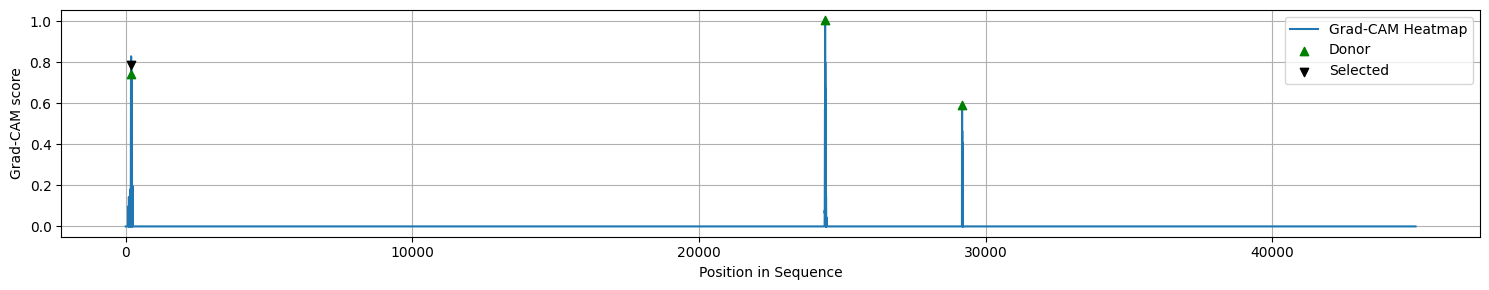

24400


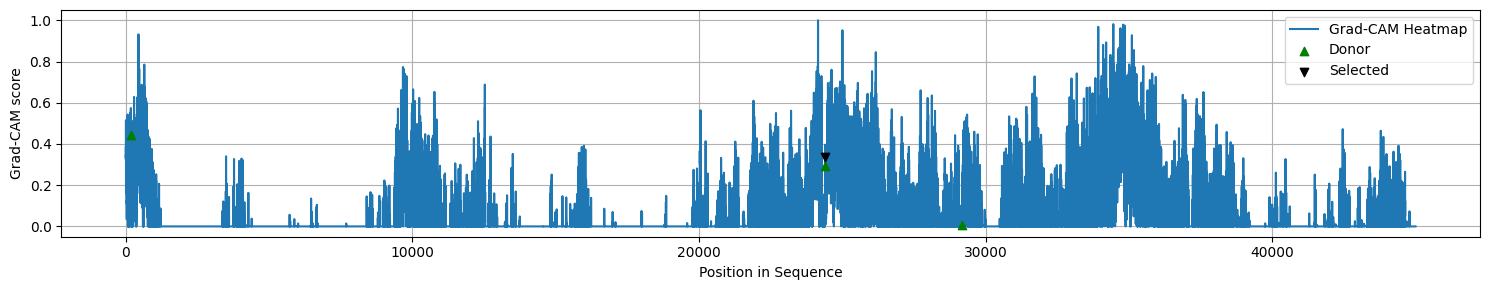

29179


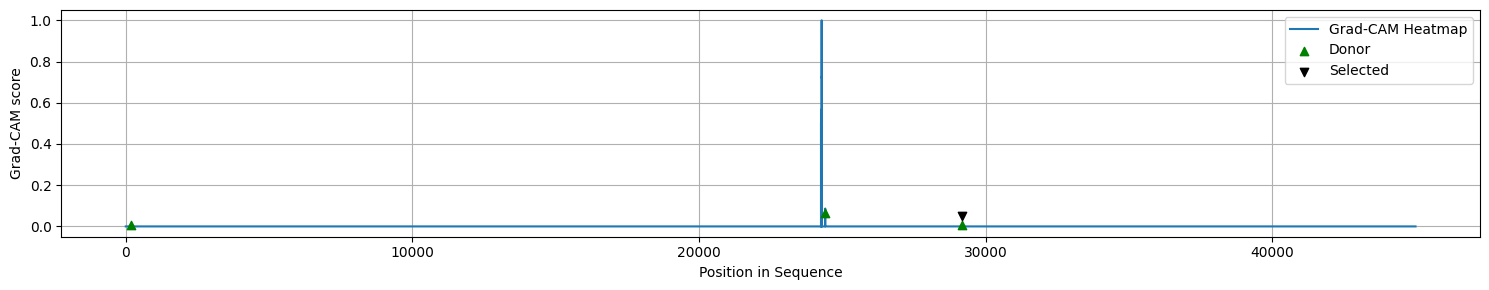

In [24]:
plot_GradCAM_full(models,batch_features,targets,20000)

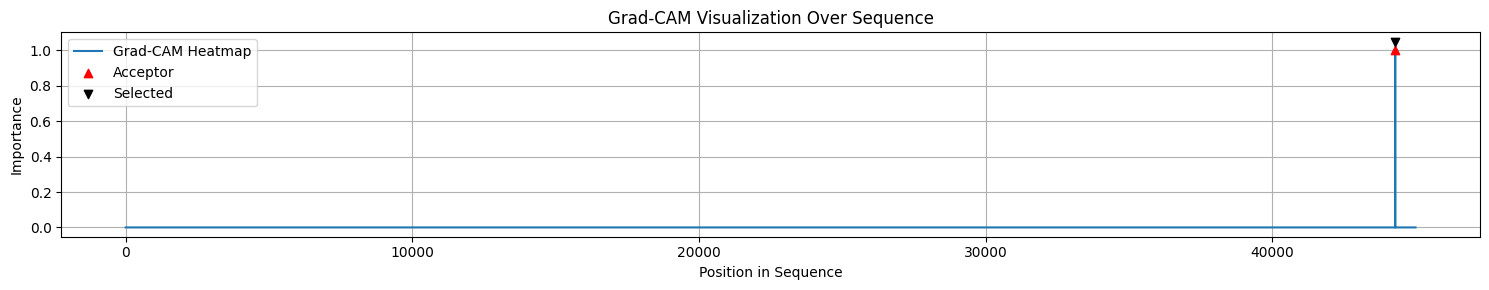

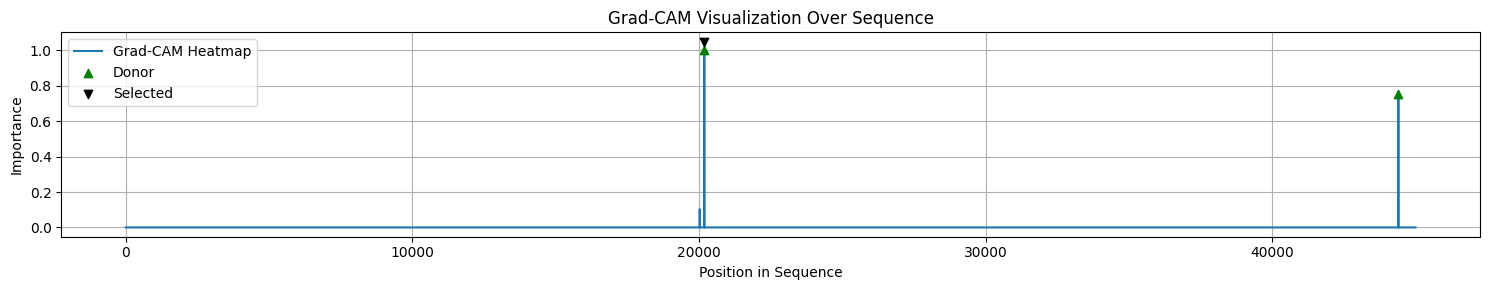

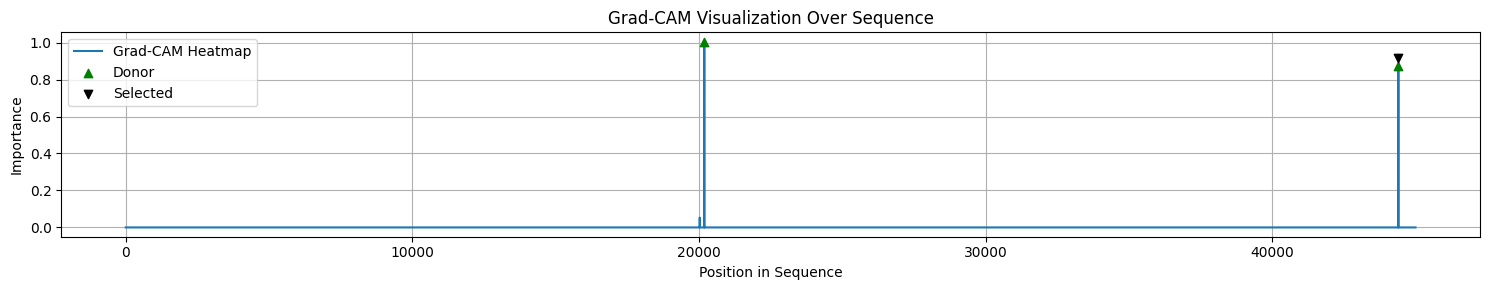

In [202]:
for label,key in zip(splice_idxs[0],splice_idxs[1]):
    grad_cam_key = torch.stack(grad_cam_dict[key-10000])
    grad_cam_key = torch.mean(grad_cam_key,dim=0)
    # grad_cam_key = grad_cam_key[1]
    relu = torch.nn.ReLU()
    grad_cam_key = relu(grad_cam_key)
    grad_cam_key = grad_cam_key.detach().numpy()
    grad_cam_key /= grad_cam_key.max()

    plt.figure(figsize=(15, 3))
    plt.plot(grad_cam_key, label='Grad-CAM Heatmap')
    if label == 1:
        plt.scatter(donor_idxs, grad_cam_key[donor_idx]+0.005,c='green',marker="^", clip_on=False, zorder=10,label='Donor')
    elif label == 0:
        plt.scatter(acceptor_idxs, grad_cam_key[acceptor_idxs]+0.005,c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')

    plt.scatter(key, grad_cam_key[key]+0.05,c='black',marker="v", clip_on=False, zorder=10,label='Selected')

    plt.xlabel('Position in Sequence')
    plt.ylabel('Importance')
    plt.title('Grad-CAM Visualization Over Sequence')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [105]:
grad_cam_full = torch.stack(grad_cam_full)
grad_cam_full = torch.mean(grad_cam_full,dim=0)
relu = torch.nn.ReLU()
grad_cam_full = relu(grad_cam_full)
grad_cam_full = grad_cam_full.detach().numpy()
grad_cam_full /= grad_cam_full.max()

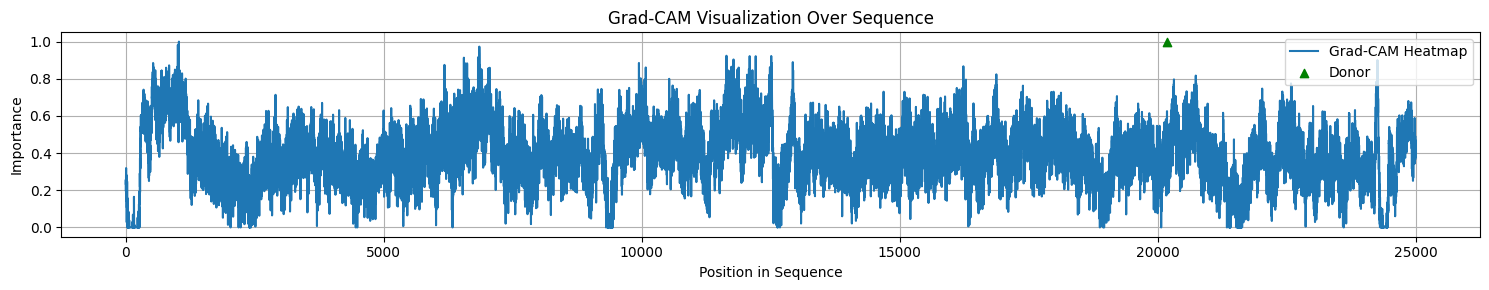

In [106]:
shift = 0
import matplotlib.pyplot as plt
import numpy as np
donor_idx = torch.nonzero(targets[2,:]).numpy() - shift
# gradcam_map is your 1D heatmap (shape: [45000])
plt.figure(figsize=(15, 3))
plt.plot(grad_cam_full[20000:], label='Grad-CAM Heatmap')
plt.scatter(20184, 1,c='green',marker="^", clip_on=False, zorder=10,label='Donor')

plt.xlabel('Position in Sequence')
plt.ylabel('Importance')
plt.title('Grad-CAM Visualization Over Sequence')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()